# 가격·기후·거시경제로 단일 모델 비교

DLinear · NLinear · XGBoost · LightGBM · PatchTST · TimesNet을 **5·20·60거래일 누적 로그수익률** 예측으로 비교한다. 모든 후보가 같은 가격·기후·거시 피처와 60거래일 창을 받는다. Persistence(가격 유지)를 기준선으로 둔다. **앙상블은 하지 않는다.** 이후 단순평균 실험에 사용할 수 있도록 개별 예측만 저장한다.

- 입력: 기존 `data/processed/2014-07-01_2025-12-31/`의 원천별 Parquet. 네트워크 수집·서비스 변경 없음.
- 학습 시작 2015년, 2014년은 입력 계산 버퍼. 검증은 2022년/2023년 expanding folds, 설정 고정 후 2024~2025년 재평가.
- **2024~2025년은 이전 실험에서 이미 본 구간이다. 미사용 Test나 live 성과가 아니다.** 검증 구간도 기존 연구에서 사용했으며 새로운 독립 검증이라고 주장하지 않는다.
- 한 seed와 제한된 설정으로 수행하는 초기 비교다. 튜닝 횟수를 맞춰도 계산량·최적화 난도가 같지는 않으며 모델의 최대 성능을 증명하지 않는다.
- 신경망은 모두 scalar-return 회귀 변형이다. PatchTST/TimesNet 원 논문의 벤치마크 재현과 구분한다.

아래 표와 그래프는 실행된 계산에서 생성된다. 기존 노트북·학습 artifact를 덮어쓰지 않는다.

### 이번 실행 결과 · seed 42

| 지평 | 검증 선택 | 선택 후보 재평가 RMSE | 사후 단일 모델 최저 | 최저 RMSE |
|---|---|---:|---|---:|
| 5거래일 | Persistence | 0.05444 | DLinear | 0.05574 |
| 20거래일 | Persistence | 0.11300 | LightGBM | 0.11251 |
| 60거래일 | DLinear | 0.16388 | PatchTST | 0.16050 |

5일은 모든 단일 모델이 Persistence보다 나빴다. 20일 사후 최저 LightGBM의 개선은 약 0.44%다. 60일 검증 선택 DLinear는 과거 재평가에서 Persistence보다 RMSE가 약 11.78% 낮았고, 사후 최저 PatchTST는 약 13.60% 낮았다. **사후 최저값으로 선택을 바꾸지 않으며 안정적 우월성을 확정하지 않는다.**


## 1. 실행 환경과 고정 설정

Mac에서는 기존 외부 Python 3.12 `~/.virtualenvs/coffee-price-prediction/bin/python`을 커널로 선택한다. 필요한 패키지는 저장소 `requirements.txt`에 있다. 이 노트북은 패키지를 설치하거나 업그레이드하지 않는다. CPU·단일 thread를 사용하며 설정을 바꾸면 전체를 처음부터 다시 실행한다.

In [1]:
import os
import sys
import platform
import tempfile
import time
import hashlib
from pathlib import Path
from datetime import datetime, timezone
from importlib.metadata import version

for key in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "VECLIB_MAXIMUM_THREADS"):
    os.environ[key] = "1"
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "coffee-matplotlib"))
os.environ.setdefault("XDG_CACHE_HOME", str(Path(tempfile.gettempdir()) / "coffee-cache"))
Path(os.environ["XDG_CACHE_HOME"]).mkdir(parents=True, exist_ok=True)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from IPython.display import display, Markdown

ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents) if (p / "coffee_service").is_dir()), None)
if ROOT is None:
    raise RuntimeError("저장소 또는 data_code 디렉터리에서 실행하세요.")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from coffee_service.transform import REGIONS, coffee_sessions, transform_market, transform_macro, transform_weather
from coffee_service.features import PRICE_FEATURES, MACRO_FEATURES, make_targets
from coffee_service.training import make_windows
from data_code.single_model_networks import make_network

FONT = {"Windows": "Malgun Gothic", "Darwin": "AppleGothic"}.get(platform.system(), "NanumGothic")
if FONT not in {f.name for f in font_manager.fontManager.ttflist}:
    raise RuntimeError(f"한글 폰트 {FONT}를 설치하고 커널을 재시작하세요.")
plt.rcParams.update({"font.family": FONT, "axes.unicode_minus": False, "figure.dpi": 110,
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 11})
torch.set_num_threads(1)
torch.use_deterministic_algorithms(True)
SEED, LOOKBACK, BATCH_SIZE = 42, 60, 64
HORIZONS = (5, 20, 60)
MODELS = ("DLinear", "NLinear", "XGBoost", "LightGBM", "PatchTST", "TimesNet")
NEURAL = ("DLinear", "NLinear", "PatchTST", "TimesNet")
EPOCHS, TREES = (10, 30), (100, 300)
SETTINGS = {name: EPOCHS if name in NEURAL else TREES for name in MODELS}
TRAIN_START = pd.Timestamp("2015-01-01")
VALIDATION_YEARS = (2022, 2023)
FINAL_CUTOFF, EVAL_END = pd.Timestamp("2023-12-31"), pd.Timestamp("2025-12-31")
DATA = ROOT / "data/processed/2014-07-01_2025-12-31"
RUN_ID = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
OUTPUT = ROOT / "data/processed/single_model_comparison" / RUN_ID

def show_table(frame, digits=5):
    display(Markdown(frame.to_markdown(index=False, floatfmt=f".{digits}f")))

show_table(pd.DataFrame([{"패키지": p, "설치 버전": version(p)} for p in
                        ("numpy", "pandas", "torch", "xgboost", "lightgbm", "scikit-learn", "nbclient")]))
print(f"Python {platform.python_version()} | CPU | {FONT} | seed {SEED} | run {RUN_ID}")

| 패키지       | 설치 버전   |
|:-------------|:------------|
| numpy        | 2.4.6       |
| pandas       | 2.3.3       |
| torch        | 2.14.0      |
| xgboost      | 3.4.1       |
| lightgbm     | 4.7.0       |
| scikit-learn | 1.7.2       |
| nbclient     | 0.11.0      |

Python 3.12.14 | CPU | AppleGothic | seed 42 | run 20260926T115735770501Z


## 2. 원천 자료와 이용 가능 시점

- 가격: 결측·OHLC 이상을 임의 보정하지 않는다. 전체 거래일 축에서 target과 창을 만든 뒤 결측 사례를 제외한다.
- 거시경제: ALFRED 최초 공개값, `release_date + 1달력일` 이후 사용.
- 기후: 브라질·콜롬비아 6개 산지의 강수·기온·가뭄·격자 서리 집계. `관측일 + 4달력일`은 기존 **이용 가능 시점 가정**이며 실제 과거 배포 기록을 보증하지 않는다.
- 월별 기후 기준값은 각 fold의 학습 cutoff까지만 적합한다. 최초 학습 구간에서 상수인 기후 피처는 제외하고 목록을 고정한다.
- NASA 기후 자료의 사후 수정, Yahoo 연속 선물의 롤오버·과거 수정 가능성은 남는다. 거래일은 기존 프로젝트 달력과 예외일을 재사용한다.

In [2]:
required = ["coffee", "alfred_dexbzus", "alfred_dff", "alfred_dcoilwtico",
            *[f"weather_{region}" for region in REGIONS]]
sources, source_rows = {}, []
for name in required:
    path = DATA / f"{name}.parquet"
    if not path.exists():
        raise FileNotFoundError(f"필수 입력 없음: {path}")
    frame = pd.read_parquet(path).sort_values("date").reset_index(drop=True)
    frame["date"] = pd.to_datetime(frame["date"]).astype("datetime64[ns]")
    if frame.date.isna().any() or frame.date.duplicated().any():
        raise ValueError(f"날짜 결측/중복: {name}")
    numeric = frame.select_dtypes(include="number")
    if (numeric <= -999).any().any():
        raise ValueError(f"원천 결측 표시를 NaN으로 처리해야 합니다: {name}")
    sources[name] = frame
    source_rows.append({"자료": name, "행 수": len(frame), "시작": frame.date.min().date(),
                        "끝": frame.date.max().date(), "SHA256": hashlib.sha256(path.read_bytes()).hexdigest()})
SESSIONS = coffee_sessions("2014-07-01", EVAL_END)
prices, price_features = transform_market(sources, SESSIONS)
if (prices.close.dropna() <= 0).any():
    raise ValueError("로그수익률 계산에 양수 가격이 필요합니다.")
macro_features, macro_availability = transform_macro(sources, SESSIONS)
Y = make_targets(prices.close, HORIZONS)
show_table(pd.DataFrame(source_rows), 0)
print("거래일 가격 결측:", SESSIONS[prices.close.isna()].strftime("%Y-%m-%d").tolist())

def build_features(data, cutoff):
    _, market = transform_market(data, SESSIONS)
    macro, macro_dates = transform_macro(data, SESSIONS)
    weather, weather_columns, weather_dates = transform_weather(data, SESSIONS, cutoff)
    frame = market.join(macro).join(weather)
    for trace in [*macro_dates.values(), *weather_dates.values()]:
        available = trace.available_at.dropna()
        assert (available <= available.index).all()
    return frame, weather_columns

FIRST_CUTOFF = pd.Timestamp(f"{VALIDATION_YEARS[0] - 1}-12-31")
first_features, weather_columns = build_features(sources, FIRST_CUTOFF)
constant_columns = [c for c in weather_columns
                    if first_features.loc[TRAIN_START:FIRST_CUTOFF, c].nunique() <= 1]
FEATURES = PRICE_FEATURES + MACRO_FEATURES + [c for c in weather_columns if c not in constant_columns]
assert len(FEATURES) == len(set(FEATURES))
show_table(pd.DataFrame({"그룹": ["가격", "거시경제", "기후·달력"],
                         "피처 수": [len(PRICE_FEATURES), len(MACRO_FEATURES), len(FEATURES)-7]}), 0)
print("제외한 최초 학습 상수:", constant_columns)
print("고정 피처 순서:", FEATURES)

| 자료                    |   행 수 | 시작       | 끝         | SHA256                                                           |
|:------------------------|--------:|:-----------|:-----------|:-----------------------------------------------------------------|
| coffee                  |    2899 | 2014-07-01 | 2025-12-31 | 2355aab560717a47333742adea40994ab537ef171be7f03501bbc3fcf270b503 |
| alfred_dexbzus          |    2999 | 2014-07-01 | 2025-12-26 | f609a20725c388ce5ec07e647ef54294c11c8f746900929b48aca9b651d94ea1 |
| alfred_dff              |    4201 | 2014-07-01 | 2025-12-30 | 2dfcade6a9a23f2e2856299ae412e42d48826b9aa37b27db36f4867ea0d533f4 |
| alfred_dcoilwtico       |    3000 | 2014-07-01 | 2025-12-29 | 4a607837b2f8c17cad9a2fe6560a1ae926247997155fe94587adff65c140a4f1 |
| weather_br_sul_minas    |    4262 | 2014-06-01 | 2026-01-30 | b9e16c56349d4e49ffdbf9b3a5f3b517303d24b8f164dfa01135a880a884a86e |
| weather_br_cerrado      |    4262 | 2014-06-01 | 2026-01-30 | 930f0a6181c6fd0b7163b4795de6230a2603cab2cb31e9da4675a7ce3c9a01b6 |
| weather_br_alta_mogiana |    4262 | 2014-06-01 | 2026-01-30 | 4eac15356880368936a3a0806f572a3ad0684f2d77973dc5ce73d36715933b0c |
| weather_co_huila        |    4262 | 2014-06-01 | 2026-01-30 | 37a00d98fb2347f111da34d7a8941a3f3b1df570ff97351cd30da3d6f7dcfaa3 |
| weather_co_caldas       |    4262 | 2014-06-01 | 2026-01-30 | 8f713ca23d47c61888fd950c7c7f694d54dc05727a3f30015c12a1d955baaaca |
| weather_co_antioquia    |    4262 | 2014-06-01 | 2026-01-30 | 707f0ae9bfb157d1cb26cfffbddfa15b5b944360baf47f67e28e8a6a8bdd7605 |

거래일 가격 결측: ['2014-09-18', '2016-10-10', '2016-11-11', '2018-12-05']


| 그룹      |   피처 수 |
|:----------|----------:|
| 가격      |         4 |
| 거시경제  |         3 |
| 기후·달력 |        20 |

제외한 최초 학습 상수: ['br_sul_minas_frost', 'br_sul_minas_drought_frost', 'br_cerrado_frost', 'br_cerrado_drought_frost', 'br_alta_mogiana_frost', 'br_alta_mogiana_drought_frost']
고정 피처 순서: ['return_1', 'return_5', 'return_20', 'volatility_20', 'brl_change_20', 'rate_change_20', 'oil_change_20', 'br_sul_minas_rain_anomaly', 'br_sul_minas_temp_anomaly', 'br_sul_minas_drought', 'br_cerrado_rain_anomaly', 'br_cerrado_temp_anomaly', 'br_cerrado_drought', 'br_alta_mogiana_rain_anomaly', 'br_alta_mogiana_temp_anomaly', 'br_alta_mogiana_drought', 'co_huila_rain_anomaly', 'co_huila_temp_anomaly', 'co_huila_drought', 'co_caldas_rain_anomaly', 'co_caldas_temp_anomaly', 'co_caldas_drought', 'co_antioquia_rain_anomaly', 'co_antioquia_temp_anomaly', 'co_antioquia_drought', 'month_sin', 'month_cos']


## 3. 시간순 평가와 공통 입력

정답은 `log(P[t+h] / P[t])`다. 예측은 t일 종가 확인 이후를 가정한다. 학습에는 **정답 날짜가 cutoff 이하인 사례만** 넣고 평가도 목표일이 해당 구간 안에 있는 사례만 포함한다. 따라서 지평이 길수록 말미의 미성숙 정답을 더 많이 제외한다.

2022년 fold는 2021년 말까지, 2023년 fold는 2022년 말까지 학습한다. 표준화는 실제 학습 창에 포함된 날짜에서만 적합한다. 평가 중 모수는 갱신하지 않고 각 origin에서 관측 가능한 입력만 새로 받는다.

신경망은 `(사례, 60일, 피처)`를, XGBoost/LightGBM은 **동일한 창을 펼친 벡터**를 받는다. 모델마다 결측 행을 달리 삭제하지 않는다. 이전 노트북의 당일 집계 피처만 받은 트리 점수와는 직접적인 재현 비교가 아니다.

In [3]:
def eligible(features, horizon, start, end):
    finite = np.isfinite(features[FEATURES].to_numpy()).all(axis=1)
    window_ok = pd.Series(finite, index=SESSIONS).rolling(LOOKBACK, min_periods=LOOKBACK).sum().eq(LOOKBACK)
    target_dates = Y[f"target_date_{horizon}"]
    mask = window_ok & np.isfinite(Y[f"y_{horizon}"]) & target_dates.le(pd.Timestamp(end))
    mask &= (SESSIONS >= pd.Timestamp(start)) & (SESSIONS <= pd.Timestamp(end))
    result = np.flatnonzero(mask)
    if not len(result):
        raise ValueError(f"유효 사례 없음: {horizon}/{start}/{end}")
    return result


def prepare(features, horizon, cutoff, eval_start, eval_end):
    train = eligible(features, horizon, TRAIN_START, cutoff)
    evaluation = eligible(features, horizon, eval_start, eval_end)
    assert Y.iloc[train][f"target_date_{horizon}"].max() <= pd.Timestamp(cutoff) < SESSIONS[evaluation[0]]
    assert np.intersect1d(train, evaluation).size == 0
    used_dates = np.unique((train[:, None] - np.arange(LOOKBACK)[None, :]).ravel())
    scaler = StandardScaler().fit(features.iloc[used_dates][FEATURES])
    values = scaler.transform(features[FEATURES]).astype("float32")
    train_x, eval_x = make_windows(values, train), make_windows(values, evaluation)
    train_y = Y.iloc[train][f"y_{horizon}"].to_numpy(float)
    mean, std = float(train_y.mean()), float(train_y.std())
    if not np.isfinite(std) or std <= 0:
        raise ValueError("학습 target 분산이 없습니다.")
    return train_x, ((train_y - mean) / std).astype("float32"), eval_x, mean, std, train, evaluation

FOLDS = [(str(year), pd.Timestamp(f"{year-1}-12-31"), pd.Timestamp(f"{year}-01-01"),
          pd.Timestamp(f"{year}-12-31")) for year in VALIDATION_YEARS]
feature_cache = {cutoff: build_features(sources, cutoff)[0]
                 for cutoff in [*[f[1] for f in FOLDS], FINAL_CUTOFF]}
split_rows = []
for fold, cutoff, start, end in [*FOLDS, ("과거 재평가", FINAL_CUTOFF, pd.Timestamp("2024-01-01"), EVAL_END)]:
    for h in HORIZONS:
        data = prepare(feature_cache[cutoff], h, cutoff, start, end)
        train, evaluation = data[-2:]
        split_rows.append({"구간": fold, "지평": h, "학습 수": len(train), "평가 수": len(evaluation),
                           "학습 정답 최종일": Y.iloc[train][f"target_date_{h}"].max().date(),
                           "첫 예측일": SESSIONS[evaluation[0]].date(), "마지막 목표일": Y.iloc[evaluation[-1]][f"target_date_{h}"].date()})
show_table(pd.DataFrame(split_rows), 0)

| 구간        |   지평 |   학습 수 |   평가 수 | 학습 정답 최종일   | 첫 예측일   | 마지막 목표일   |
|:------------|-------:|----------:|----------:|:-------------------|:------------|:----------------|
| 2022        |      5 |      1566 |       246 | 2021-12-31         | 2022-01-03  | 2022-12-30      |
| 2022        |     20 |      1551 |       231 | 2021-12-31         | 2022-01-03  | 2022-12-30      |
| 2022        |     60 |      1510 |       191 | 2021-12-31         | 2022-01-03  | 2022-12-30      |
| 2023        |      5 |      1817 |       245 | 2022-12-30         | 2023-01-03  | 2023-12-29      |
| 2023        |     20 |      1802 |       230 | 2022-12-30         | 2023-01-03  | 2023-12-29      |
| 2023        |     60 |      1761 |       190 | 2022-12-30         | 2023-01-03  | 2023-12-29      |
| 과거 재평가 |      5 |      2067 |       498 | 2023-12-29         | 2024-01-02  | 2025-12-31      |
| 과거 재평가 |     20 |      2052 |       483 | 2023-12-29         | 2024-01-02  | 2025-12-31      |
| 과거 재평가 |     60 |      2011 |       443 | 2023-12-29         | 2024-01-02  | 2025-12-31      |

## 4. 모델 구조와 학습 규칙

| 모델 | 이 노트북의 입력·회귀 변형 |
|---|---|
| DLinear | 기존 서비스의 이동평균(5) 분해 + 두 시간 선형층 + 채널 회귀 head 재사용. 기존 가중치는 사용하지 않음 |
| NLinear | 채널별 마지막 값 제거 → 시간 선형층 → 같은 채널 단위 값 복원 → 수익률 회귀 head |
| XGBoost / LightGBM | 동일한 60일 창의 모든 lag를 펼친 회귀 입력, 깊이 4·학습률 0.03·L2 5 |
| PatchTST | 채널 독립 패치 Transformer를 scalar 회귀로 적용. 작은 네트워크와 채널 통합 head 사용 |
| TimesNet | FFT 주기 선택 → 2D reshape·다중 kernel convolution·주기 결합 → scalar 회귀 |

정확한 구조는 옆의 `single_model_networks.py`에 공개한다. 논문의 전체 forecast head/실험 설정을 그대로 재현하지 않는다. 따라서 아래 결과는 **이 프로젝트의 회귀 변형과 제한된 설정의 비교**다.

신경망은 AdamW(lr=0.001, weight_decay=0.01), gradient clipping=1, batch=64로 10/30 epoch checkpoint를 비교한다. 트리는 100/300개를 비교한다. 두 검증 fold의 **전체 squared error를 합산한 RMSE**로 모델별 설정을 고른다. 동률이면 작은 설정을 선택한다. 재평가에서 다시 고르지 않는다.

- [DACON 참고 글](https://dacon.io/competitions/official/236264/codeshare/10891)
- [DLinear/NLinear 공식 설명](https://github.com/cure-lab/LTSF-Linear)
- [PatchTST 공식 구현](https://github.com/yuqinie98/PatchTST)
- [TimesNet 공식 구현](https://github.com/thuml/Time-Series-Library/blob/main/models/TimesNet.py)
- [XGBoost API](https://xgboost.readthedocs.io/en/stable/python/python_api.html), [LightGBM API](https://lightgbm.readthedocs.io/en/stable/pythonapi/lightgbm.LGBMRegressor.html)
- [시간순 검증](https://otexts.com/fpp3/tscv.html)

출처 확인일: 2026-09-26. 기존 설치 버전을 유지했다.

In [4]:
def predict_network(model, values):
    model.eval()
    chunks = []
    with torch.no_grad():
        for start in range(0, len(values), BATCH_SIZE):
            chunks.append(model(torch.from_numpy(values[start:start+BATCH_SIZE])).numpy())
    predicted = np.concatenate(chunks)
    if predicted.shape != (len(values),) or not np.isfinite(predicted).all():
        raise ValueError("신경망 예측 shape/유한값 오류")
    return predicted


def fit_candidates(name, settings, train_x, train_y, eval_x):
    start_time = time.perf_counter()
    results = {}
    if name in NEURAL:
        torch.manual_seed(SEED)
        model = make_network(name, train_x.shape[-1], LOOKBACK)
        generator = torch.Generator().manual_seed(SEED)
        loader = DataLoader(TensorDataset(torch.from_numpy(train_x), torch.from_numpy(train_y)),
                            batch_size=BATCH_SIZE, shuffle=True, generator=generator)
        optimizer = torch.optim.AdamW(model.parameters(), lr=.001, weight_decay=.01)
        for epoch in range(1, max(settings)+1):
            model.train()
            for batch_x, batch_y in loader:
                optimizer.zero_grad()
                loss = nn.functional.mse_loss(model(batch_x), batch_y)
                if not torch.isfinite(loss):
                    raise ValueError(f"{name}: 비유한 학습 손실")
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1., error_if_nonfinite=True)
                optimizer.step()
            if epoch in settings:
                prediction = predict_network(model, eval_x)
                results[epoch] = (prediction, time.perf_counter() - start_time)
    else:
        train_flat, eval_flat = train_x.reshape(len(train_x), -1), eval_x.reshape(len(eval_x), -1)
        columns = [f"lag_{lag}_{column}" for lag in range(LOOKBACK-1, -1, -1) for column in FEATURES]
        train_flat, eval_flat = pd.DataFrame(train_flat, columns=columns), pd.DataFrame(eval_flat, columns=columns)
        for trees in settings:
            start_time = time.perf_counter()
            common = dict(n_estimators=trees, max_depth=4, learning_rate=.03, reg_lambda=5,
                          random_state=SEED, n_jobs=1)
            if name == "XGBoost":
                model = XGBRegressor(**common, objective="reg:squarederror", tree_method="hist")
            elif name == "LightGBM":
                model = LGBMRegressor(**common, num_leaves=15, min_child_samples=40,
                                      deterministic=True, force_col_wise=True, verbosity=-1)
            else:
                raise ValueError(name)
            model.fit(train_flat, train_y)
            results[trees] = (model.predict(eval_flat), time.perf_counter() - start_time)
    return results


def metrics(actual, predicted, current):
    actual, predicted, current = map(lambda x: np.asarray(x, dtype=float), (actual, predicted, current))
    if actual.shape != predicted.shape or actual.shape != current.shape or not np.isfinite([actual, predicted, current]).all():
        raise ValueError("지표 입력은 같은 shape의 유한 배열이어야 합니다.")
    rmse = np.sqrt(np.mean((actual - predicted)**2))
    naive_rmse = np.sqrt(np.mean(actual**2))
    actual_price, predicted_price = current*np.exp(actual), current*np.exp(predicted)
    if not np.isfinite(predicted_price).all():
        raise ValueError("복원 가격이 유한하지 않습니다.")
    recalls = [np.mean(np.sign(predicted[actual*sign > 0]) == sign)
               for sign in (-1, 1) if (actual*sign > 0).any()]
    return {"표본": len(actual), "RMSE": rmse, "MAE": np.mean(np.abs(actual-predicted)),
            "가격 RMSE": np.sqrt(np.mean((actual_price-predicted_price)**2)),
            "가격 MAE": np.mean(np.abs(actual_price-predicted_price)),
            "방향 정확도 (%)": 100*np.mean(np.sign(actual) == np.sign(predicted)),
            "방향 균형 정확도 (%)": 100*np.mean(recalls) if len(recalls)==2 else np.nan,
            "Persistence 대비 개선 (%)": 100*(1-rmse/naive_rmse) if naive_rmse > 0 else np.nan}


def prediction_frame(split, fold, h, name, setting, indices, predicted, cutoff):
    predicted = np.asarray(predicted)
    if predicted.shape != (len(indices),) or not np.isfinite(predicted).all():
        raise ValueError(f"{name}: 비유한 예측 또는 행 불일치")
    return pd.DataFrame({"split": split, "fold": fold, "horizon": h, "model": name,
                         "setting": setting, "seed": SEED, "train_cutoff": cutoff,
                         "origin_date": SESSIONS[indices], "target_date": Y.iloc[indices][f"target_date_{h}"].to_numpy(),
                         "actual_return": Y.iloc[indices][f"y_{h}"].to_numpy(), "predicted_return": predicted,
                         "current_price": prices.close.iloc[indices].to_numpy()})


def score_predictions(frame):
    return metrics(frame.actual_return, frame.predicted_return, frame.current_price)

## 5. 먼저 검사하고 시간순 검증 실행

아래 검사는 미래 자료 변경이 과거 입력에 영향을 주지 않는지, h가 실제 거래일 이동인지, 창 안의 결측이 보존되는지 확인한다. 이 검사가 원천 자료의 사후 수정 가능성을 없애지는 않는다.

In [5]:
# 학습 cutoff 이후 공개 가능한 원천값을 바꿔도 과거 feature는 같아야 한다.
changed_sources = {key: value.copy(deep=True) for key, value in sources.items()}
for key, frame in changed_sources.items():
    if key.startswith("alfred_"):
        available = pd.to_datetime(frame.release_date) + pd.Timedelta(days=1)
        columns = ["value"]
    elif key.startswith("weather_"):
        available = frame.date + pd.Timedelta(days=4)
        columns = ["PRECTOTCORR", "T2M", "T2M_MIN"]
    else:
        available, columns = frame.date, ["close"]
    frame.loc[available > FIRST_CUTOFF, columns] *= 1.7
changed_features, _ = build_features(changed_sources, FIRST_CUTOFF)
pd.testing.assert_frame_equal(first_features.loc[:FIRST_CUTOFF], changed_features.loc[:FIRST_CUTOFF])

toy = pd.Series(np.arange(100., 280.), index=pd.bdate_range("2020-01-01", periods=180))
toy.iloc[20] = np.nan
toy_targets = make_targets(toy, HORIZONS)
for h in HORIZONS:
    assert pd.isna(toy_targets.iloc[20][f"y_{h}"])
    assert toy_targets.iloc[30][f"target_date_{h}"] == toy.index[30+h]
    np.testing.assert_allclose(toy_targets.iloc[30][f"y_{h}"], np.log(toy.iloc[30+h]/toy.iloc[30]))
zero_check = metrics([.1, -.1], [0., 0.], [100., 100.])
assert zero_check["방향 정확도 (%)"] == 0 and zero_check["방향 균형 정확도 (%)"] == 0
assert zero_check["Persistence 대비 개선 (%)"] == 0
print("미래 입력 차단·target 날짜·결측·Persistence 지표 검사 통과")

미래 입력 차단·target 날짜·결측·Persistence 지표 검사 통과


In [6]:
validation_parts, timing_rows = [], []
for fold, cutoff, start, end in FOLDS:
    features = feature_cache[cutoff]
    for h in HORIZONS:
        train_x, train_y, eval_x, mean, std, train, evaluation = prepare(features, h, cutoff, start, end)
        validation_parts.append(prediction_frame("validation", fold, h, "Persistence", 0,
                                                evaluation, np.zeros(len(evaluation)), cutoff))
        for name in MODELS:
            fitted = fit_candidates(name, SETTINGS[name], train_x, train_y, eval_x)
            for setting, (scaled_prediction, seconds) in fitted.items():
                validation_parts.append(prediction_frame("validation", fold, h, name, setting,
                                                        evaluation, scaled_prediction*std+mean, cutoff))
                timing_rows.append({"구간": fold, "지평": h, "모델": name, "설정": setting, "초": seconds})
            print(f"검증 {fold} | {h:2d}일 | {name:8s} | {seconds:.1f}초", flush=True)
validation_predictions = pd.concat(validation_parts, ignore_index=True)
validation_rows = []
for (h, name, setting), frame in validation_predictions.groupby(["horizon", "model", "setting"], sort=False):
    validation_rows.append({"지평": h, "모델": name, "설정": setting, **score_predictions(frame)})
validation_scores = pd.DataFrame(validation_rows)
selected = (validation_scores.sort_values(["지평", "모델", "RMSE", "설정"])
            .drop_duplicates(["지평", "모델"]).sort_values(["지평", "RMSE"]).reset_index(drop=True))
chosen_setting = {(int(row["지평"]), row["모델"]): int(row["설정"]) for row in selected.to_dict("records")}
chosen_model = {h: selected.loc[selected["지평"].eq(h)].sort_values(["RMSE", "설정", "모델"]).iloc[0]["모델"]
                for h in HORIZONS}
show_table(selected[["지평", "모델", "설정", "표본", "RMSE", "MAE", "Persistence 대비 개선 (%)"]])
print("검증에서 선택한 후보(가격 유지 포함):", chosen_model)

검증 2022 |  5일 | DLinear  | 1.1초


검증 2022 |  5일 | NLinear  | 0.4초


검증 2022 |  5일 | XGBoost  | 17.0초


검증 2022 |  5일 | LightGBM | 5.9초


검증 2022 |  5일 | PatchTST | 20.0초


...

검증 2023 | 60일 | LightGBM | 8.0초


검증 2023 | 60일 | PatchTST | 24.0초


검증 2023 | 60일 | TimesNet | 18.2초


|   지평 | 모델        |   설정 |   표본 |    RMSE |     MAE |   Persistence 대비 개선 (%) |
|-------:|:------------|-------:|-------:|--------:|--------:|----------------------------:|
|      5 | Persistence |      0 |    491 | 0.04695 | 0.03758 |                     0.00000 |
|      5 | TimesNet    |     10 |    491 | 0.04797 | 0.03771 |                    -2.19056 |
|      5 | NLinear     |     10 |    491 | 0.04812 | 0.03801 |                    -2.50794 |
|      5 | LightGBM    |    100 |    491 | 0.04840 | 0.03838 |                    -3.09105 |
|      5 | XGBoost     |    100 |    491 | 0.04848 | 0.03843 |                    -3.27604 |
|      5 | DLinear     |     10 |    491 | 0.04859 | 0.03792 |                    -3.50279 |
|      5 | PatchTST    |     10 |    491 | 0.05087 | 0.04071 |                    -8.35884 |
|     20 | Persistence |      0 |    461 | 0.09185 | 0.07380 |                     0.00000 |
|     20 | XGBoost     |    100 |    461 | 0.09561 | 0.07646 |                    -4.09720 |
|     20 | NLinear     |     10 |    461 | 0.09582 | 0.07665 |                    -4.31607 |
|     20 | LightGBM    |    100 |    461 | 0.09654 | 0.07744 |                    -5.10647 |
|     20 | DLinear     |     10 |    461 | 0.10765 | 0.08747 |                   -17.19689 |
|     20 | TimesNet    |     10 |    461 | 0.11119 | 0.09128 |                   -21.05783 |
|     20 | PatchTST    |     10 |    461 | 0.12068 | 0.10350 |                   -31.38952 |
|     60 | DLinear     |     10 |    381 | 0.14621 | 0.11622 |                     8.58766 |
|     60 | XGBoost     |    100 |    381 | 0.15789 | 0.12997 |                     1.28271 |
|     60 | NLinear     |     10 |    381 | 0.15927 | 0.12579 |                     0.42327 |
|     60 | LightGBM    |    100 |    381 | 0.15980 | 0.13166 |                     0.09123 |
|     60 | Persistence |      0 |    381 | 0.15994 | 0.12049 |                     0.00000 |
|     60 | TimesNet    |     10 |    381 | 0.17267 | 0.14366 |                    -7.95573 |
|     60 | PatchTST    |     10 |    381 | 0.20463 | 0.17244 |                   -27.93649 |

검증에서 선택한 후보(가격 유지 포함): {5: 'Persistence', 20: 'Persistence', 60: 'DLinear'}


## 6. 설정을 고정하고 2024~2025년 과거 재평가

각 모델의 검증 선택 설정으로 2015~2023년을 재학습한다. 기후 기준값·입력 및 target 표준화도 이 학습 범위에서 다시 적합한다. **재평가 결과를 보고 모델·피처·설정을 바꾸지 않는다.** 이 단계는 이미 본 과거의 기술적 재평가이며 일반화 성능의 독립 증거가 아니다.

In [7]:
evaluation_parts = []
for h in HORIZONS:
    train_x, train_y, eval_x, mean, std, train, evaluation = prepare(
        feature_cache[FINAL_CUTOFF], h, FINAL_CUTOFF, "2024-01-01", EVAL_END)
    evaluation_parts.append(prediction_frame("historical", "2024–2025", h, "Persistence", 0,
                                            evaluation, np.zeros(len(evaluation)), FINAL_CUTOFF))
    for name in MODELS:
        setting = chosen_setting[h, name]
        scaled_prediction, seconds = fit_candidates(name, (setting,), train_x, train_y, eval_x)[setting]
        evaluation_parts.append(prediction_frame("historical", "2024–2025", h, name, setting,
                                                evaluation, scaled_prediction*std+mean, FINAL_CUTOFF))
        timing_rows.append({"구간": "과거 재평가", "지평": h, "모델": name, "설정": setting, "초": seconds})
        print(f"재평가 | {h:2d}일 | {name:8s} | {seconds:.1f}초", flush=True)
evaluation_predictions = pd.concat(evaluation_parts, ignore_index=True)
evaluation_rows = []
for (h, name, setting), frame in evaluation_predictions.groupby(["horizon", "model", "setting"], sort=False):
    evaluation_rows.append({"지평": h, "모델": name, "설정": setting,
                            "검증 선택": "선택" if chosen_model[h]==name else "", **score_predictions(frame)})
evaluation_scores = pd.DataFrame(evaluation_rows)
for h in HORIZONS:
    display(Markdown(f"### {h}거래일 · 과거 재평가 (2024~2025년)"))
    show_table(evaluation_scores.loc[evaluation_scores["지평"].eq(h)].sort_values("RMSE"))

재평가 |  5일 | DLinear  | 0.5초


재평가 |  5일 | NLinear  | 0.2초


재평가 |  5일 | XGBoost  | 7.1초


재평가 |  5일 | LightGBM | 3.0초


재평가 |  5일 | PatchTST | 9.2초


...

|   지평 | 모델        |   설정 | 검증 선택   |   표본 |    RMSE |     MAE |   가격 RMSE |   가격 MAE |   방향 정확도 (%) |   방향 균형 정확도 (%) |   Persistence 대비 개선 (%) |
|-------:|:------------|-------:|:------------|-------:|--------:|--------:|------------:|-----------:|------------------:|-----------------------:|----------------------------:|
|      5 | Persistence |      0 | 선택        |    498 | 0.05444 | 0.04281 |    17.57075 |   13.21556 |           0.40161 |                0.00000 |                     0.00000 |
|      5 | DLinear     |     10 |             |    498 | 0.05574 | 0.04367 |    17.95703 |   13.47998 |          52.40964 |               51.86764 |                    -2.38359 |
|      5 | NLinear     |     10 |             |    498 | 0.05585 | 0.04403 |    18.01032 |   13.59667 |          51.40562 |               51.85532 |                    -2.57759 |
|      5 | PatchTST    |     10 |             |    498 | 0.05654 | 0.04469 |    18.30931 |   13.81502 |          48.19277 |               47.11805 |                    -3.85213 |
|      5 | LightGBM    |    100 |             |    498 | 0.05735 | 0.04506 |    18.63932 |   13.94544 |          51.40562 |               50.00739 |                    -5.33305 |
|      5 | XGBoost     |    100 |             |    498 | 0.05743 | 0.04523 |    18.67819 |   14.00558 |          51.00402 |               49.31257 |                    -5.48804 |
|      5 | TimesNet    |     10 |             |    498 | 0.06395 | 0.05062 |    20.64341 |   15.58828 |          52.61044 |               53.11848 |                   -17.46697 |

### 20거래일 · 과거 재평가 (2024~2025년)

|   지평 | 모델        |   설정 | 검증 선택   |   표본 |    RMSE |     MAE |   가격 RMSE |   가격 MAE |   방향 정확도 (%) |   방향 균형 정확도 (%) |   Persistence 대비 개선 (%) |
|-------:|:------------|-------:|:------------|-------:|--------:|--------:|------------:|-----------:|------------------:|-----------------------:|----------------------------:|
|     20 | LightGBM    |    100 |             |    483 | 0.11251 | 0.08399 |    36.15574 |   25.95147 |          56.93582 |               58.33750 |                     0.44019 |
|     20 | DLinear     |     10 |             |    483 | 0.11269 | 0.08946 |    36.37130 |   27.74263 |          53.41615 |               55.73520 |                     0.27615 |
|     20 | XGBoost     |    100 |             |    483 | 0.11287 | 0.08435 |    36.38137 |   26.15077 |          58.59213 |               59.63686 |                     0.12254 |
|     20 | Persistence |      0 | 선택        |    483 | 0.11300 | 0.08538 |    36.09749 |   26.46180 |           0.00000 |                0.00000 |                     0.00000 |
|     20 | NLinear     |     10 |             |    483 | 0.11851 | 0.09036 |    37.71201 |   27.72154 |          55.69358 |               53.99529 |                    -4.87469 |
|     20 | TimesNet    |     10 |             |    483 | 0.12504 | 0.09332 |    41.08551 |   29.32017 |          59.62733 |               58.97692 |                   -10.64911 |
|     20 | PatchTST    |     10 |             |    483 | 0.13067 | 0.10123 |    42.57117 |   31.64477 |          50.10352 |               49.06985 |                   -15.63035 |

### 60거래일 · 과거 재평가 (2024~2025년)

|   지평 | 모델        |   설정 | 검증 선택   |   표본 |    RMSE |     MAE |   가격 RMSE |   가격 MAE |   방향 정확도 (%) |   방향 균형 정확도 (%) |   Persistence 대비 개선 (%) |
|-------:|:------------|-------:|:------------|-------:|--------:|--------:|------------:|-----------:|------------------:|-----------------------:|----------------------------:|
|     60 | PatchTST    |     10 |             |    443 | 0.16050 | 0.12723 |    53.24492 |   41.31251 |          63.88262 |               47.13978 |                    13.59798 |
|     60 | DLinear     |     10 | 선택        |    443 | 0.16388 | 0.12924 |    52.37094 |   40.31193 |          81.94131 |               85.01843 |                    11.78141 |
|     60 | NLinear     |     10 |             |    443 | 0.17292 | 0.13777 |    56.62684 |   44.00050 |          68.84876 |               71.60061 |                     6.91070 |
|     60 | XGBoost     |    100 |             |    443 | 0.17847 | 0.14659 |    57.49174 |   45.95726 |          59.36795 |               64.81106 |                     3.92354 |
|     60 | TimesNet    |     10 |             |    443 | 0.17899 | 0.14608 |    61.78411 |   48.69196 |          62.75395 |               43.26728 |                     3.64398 |
|     60 | LightGBM    |    100 |             |    443 | 0.17910 | 0.14552 |    57.33634 |   45.40203 |          62.30248 |               69.43164 |                     3.58720 |
|     60 | Persistence |      0 |             |    443 | 0.18576 | 0.15822 |    58.83049 |   48.53251 |           0.00000 |                0.00000 |                     0.00000 |

## 7. 지평별 오차와 기간별 안정성

방향 정확도는 가격 오차와 별도 지표다. 방향 균형 정확도는 실제 상승·하락의 recall 평균이며 예측 보합은 상승/하락을 맞힌 것으로 세지 않는다. 실제 보합은 균형 정확도에서 제외한다. 방향 정확도 50%만으로 예측력을 판단하지 않는다.

RMSE 막대는 0부터 시작한다. 지평별 수익률 규모가 다르므로 지평 사이 절대 RMSE를 모델 우열로 해석하지 않는다.

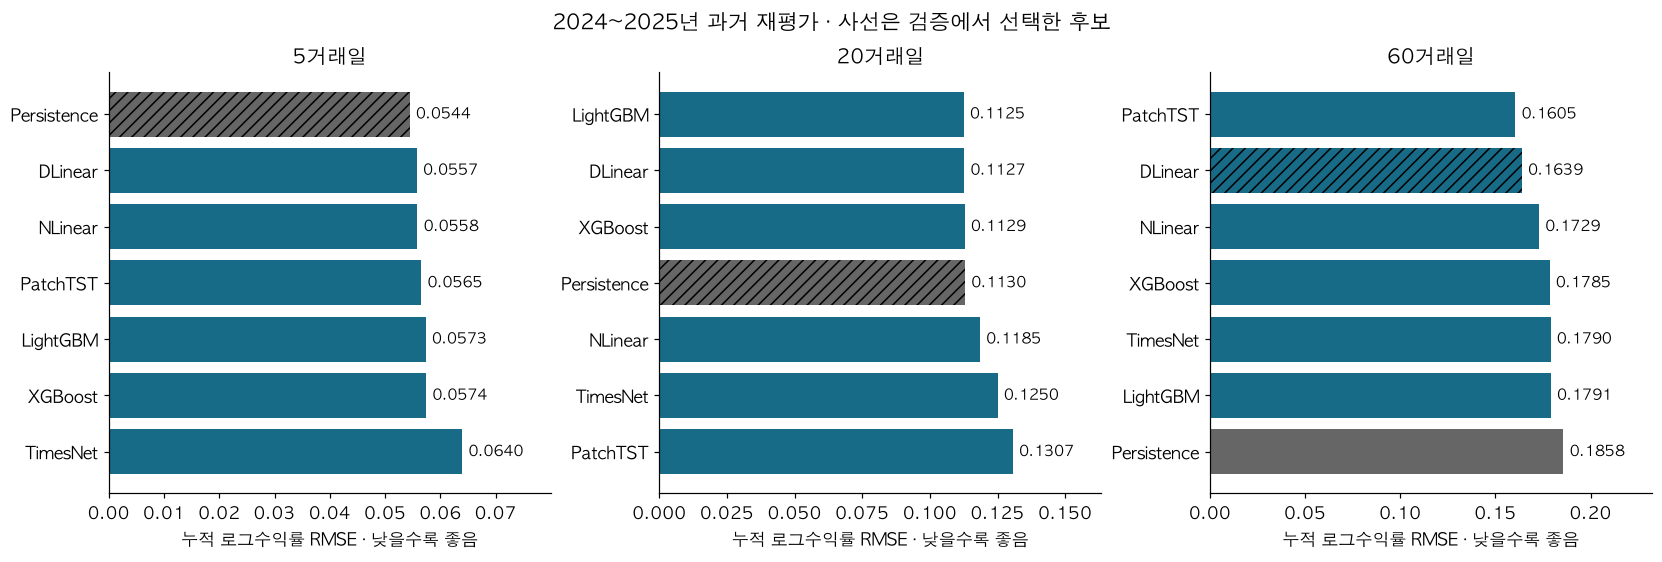

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), layout="constrained")
for ax, h in zip(axes, HORIZONS):
    table = evaluation_scores.loc[evaluation_scores["지평"].eq(h)].sort_values("RMSE", ascending=False)
    colors = ["#666666" if m=="Persistence" else "#176B87" for m in table["모델"]]
    bars = ax.barh(table["모델"], table["RMSE"], color=colors)
    for bar, is_chosen in zip(bars, table["검증 선택"].eq("선택")):
        if is_chosen:
            bar.set_hatch("///")
    ax.bar_label(bars, fmt="%.4f", padding=4, fontsize=10)
    ax.set_xlim(0, table["RMSE"].max()*1.25)
    ax.set_title(f"{h}거래일")
    ax.set_xlabel("누적 로그수익률 RMSE · 낮을수록 좋음")
fig.suptitle("2024~2025년 과거 재평가 · 사선은 검증에서 선택한 후보", fontsize=14)
plt.show()

**5거래일 · 연도별 Persistence 대비 RMSE 개선율 (%)**

| 모델        |   2024 |   2025 |
|:------------|-------:|-------:|
| DLinear     |  -2.69 |  -2.17 |
| LightGBM    |  -2.42 |  -7.27 |
| NLinear     |  -2.43 |  -2.68 |
| PatchTST    |   0.97 |  -7.01 |
| Persistence |   0.00 |   0.00 |
| TimesNet    | -12.42 | -20.78 |
| XGBoost     |  -2.36 |  -7.57 |

**20거래일 · 연도별 Persistence 대비 RMSE 개선율 (%)**

| 모델        |   2024 |   2025 |
|:------------|-------:|-------:|
| DLinear     |  -0.12 |   0.54 |
| LightGBM    |   6.23 |  -3.29 |
| NLinear     |  -3.63 |  -5.71 |
| PatchTST    |  -1.34 | -24.35 |
| Persistence |   0.00 |   0.00 |
| TimesNet    |  13.95 | -24.54 |
| XGBoost     |   5.55 |  -3.38 |

**60거래일 · 연도별 Persistence 대비 RMSE 개선율 (%)**

| 모델        |   2024 |   2025 |
|:------------|-------:|-------:|
| DLinear     |   1.35 |  30.49 |
| LightGBM    |  -0.37 |   9.91 |
| NLinear     |   3.49 |  12.35 |
| PatchTST    |  15.36 |  11.00 |
| Persistence |   0.00 |   0.00 |
| TimesNet    |  33.99 | -29.40 |
| XGBoost     |   2.11 |   6.73 |

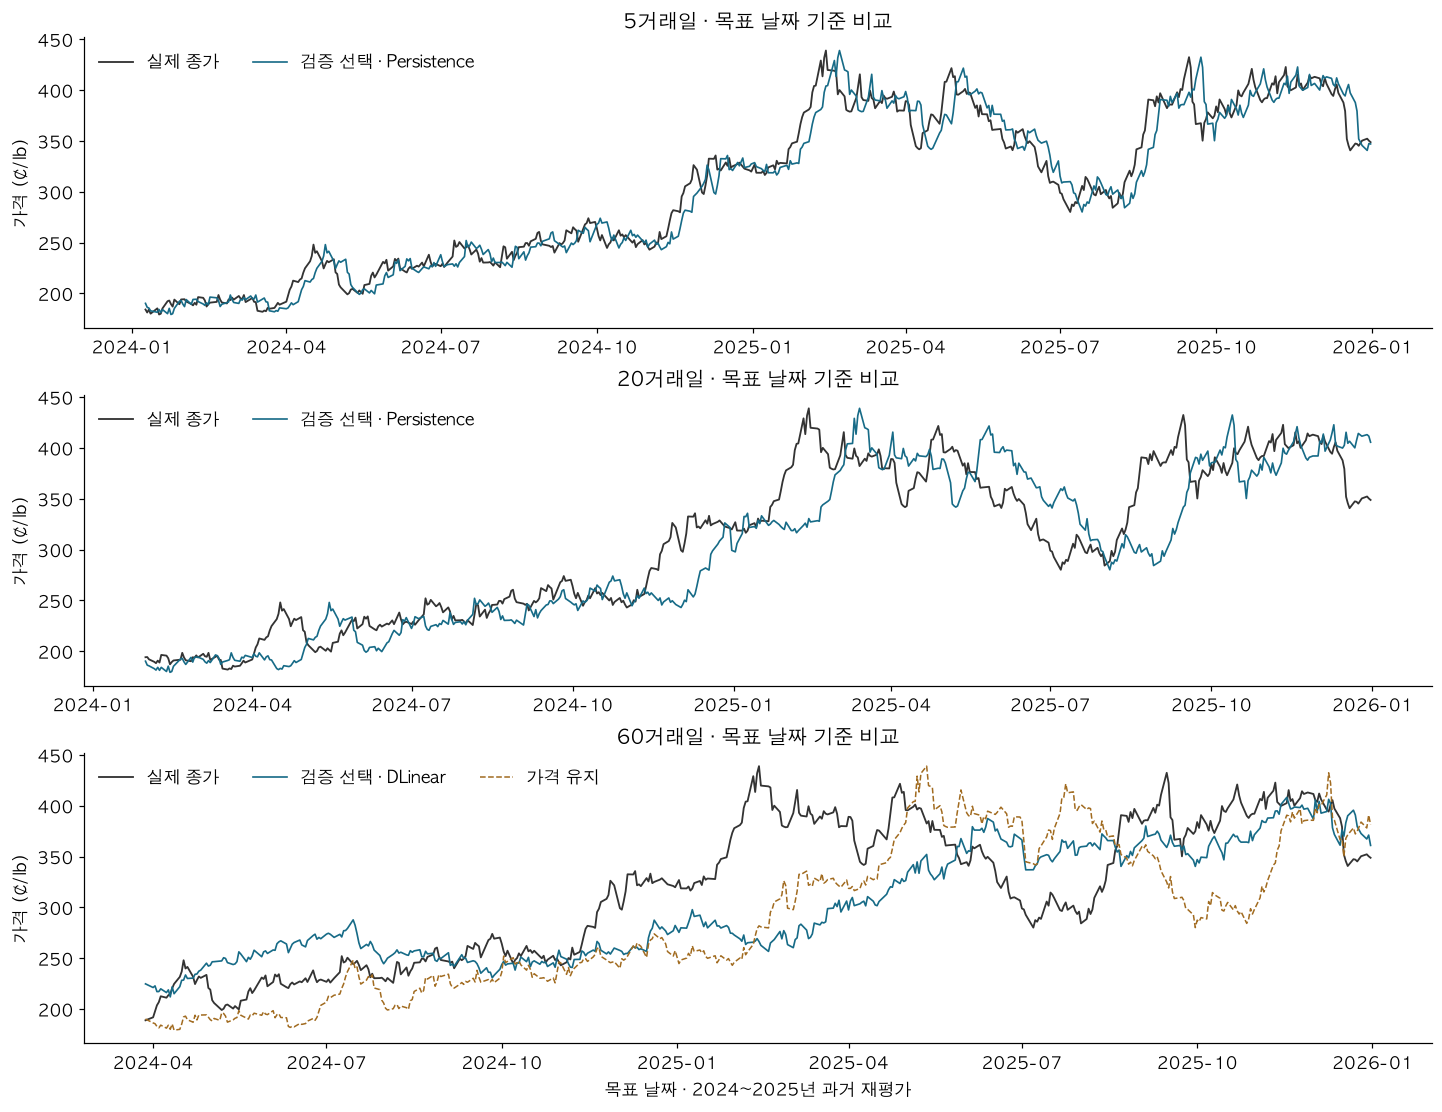

In [9]:
period_rows = []
for (h, name, year), frame in evaluation_predictions.groupby(
        ["horizon", "model", evaluation_predictions.origin_date.dt.year]):
    period_rows.append({"지평": h, "모델": name, "기준일 연도": year, **score_predictions(frame)})
period_scores = pd.DataFrame(period_rows)
for h in HORIZONS:
    display(Markdown(f"**{h}거래일 · 연도별 Persistence 대비 RMSE 개선율 (%)**"))
    show_table(period_scores.loc[period_scores["지평"].eq(h)].pivot(
        index="모델", columns="기준일 연도", values="Persistence 대비 개선 (%)").reset_index(), 2)

fig, axes = plt.subplots(3, 1, figsize=(13, 10), layout="constrained")
for ax, h in zip(axes, HORIZONS):
    name = chosen_model[h]
    frame = evaluation_predictions.loc[(evaluation_predictions.horizon==h) & (evaluation_predictions.model==name)].sort_values("target_date")
    ax.plot(frame.target_date, frame.current_price*np.exp(frame.actual_return), color="#333333", label="실제 종가", linewidth=1.2)
    ax.plot(frame.target_date, frame.current_price*np.exp(frame.predicted_return), color="#176B87", label=f"검증 선택 · {name}", linewidth=1.1)
    if name != "Persistence":
        ax.plot(frame.target_date, frame.current_price, color="#A16B20", linestyle="--", label="가격 유지", linewidth=1)
    ax.set_title(f"{h}거래일 · 목표 날짜 기준 비교")
    ax.set_ylabel("가격 (¢/lb)")
    ax.legend(loc="upper left", ncol=3, frameon=False)
axes[-1].set_xlabel("목표 날짜 · 2024~2025년 과거 재평가")
plt.show()

### 중첩 target의 민감도

60일 누적수익률은 인접 표본끼리 같은 가격 구간을 공유한다. 아래는 각 지평에서 origin 간격을 h 이상 띄운 시작점 세 가지의 결과다. **시작점별 표본은 서로 독립인 새 데이터가 아니며 합쳐 표본 수를 늘리지 않는다.** 작은 차이의 통계적 유의성이나 안정적 우월성은 주장하지 않는다.

In [10]:
sensitivity_rows = []
for (h, name), frame in evaluation_predictions.groupby(["horizon", "model"]):
    indices = SESSIONS.get_indexer(frame.origin_date)
    for offset in sorted({0, h//3, 2*h//3}):
        keep = (indices-indices.min()-offset) % h == 0
        part = frame.loc[keep]
        assert np.all(np.diff(indices[keep]) >= h)
        if len(part):
            sensitivity_rows.append({"지평": h, "모델": name, "시작 offset": offset, **score_predictions(part)})
sensitivity_scores = pd.DataFrame(sensitivity_rows)
summary = sensitivity_scores.groupby(["지평", "모델"], as_index=False).agg(
    최소_표본=("표본", "min"), 개선율_최소=("Persistence 대비 개선 (%)", "min"),
    개선율_최대=("Persistence 대비 개선 (%)", "max"))
show_table(summary, 2)
show_table(pd.DataFrame(timing_rows).groupby(["구간", "모델"], as_index=False)["초"].max().rename(columns={"초": "지평별 최대 실행 초"}), 1)
print("신경망 checkpoint 시간은 누적 시간이며 서로 합산하지 않습니다.")

|   지평 | 모델        |   최소_표본 |   개선율_최소 |   개선율_최대 |
|-------:|:------------|------------:|--------------:|--------------:|
|      5 | DLinear     |          99 |         -3.97 |         -0.80 |
|      5 | LightGBM    |          99 |         -7.21 |         -4.06 |
|      5 | NLinear     |          99 |         -4.13 |         -2.10 |
|      5 | PatchTST    |          99 |         -5.07 |         -3.29 |
|      5 | Persistence |          99 |          0.00 |          0.00 |
|      5 | TimesNet    |          99 |        -22.16 |        -14.35 |
|      5 | XGBoost     |          99 |         -7.32 |         -3.50 |
|     20 | DLinear     |          24 |         -4.37 |          1.69 |
|     20 | LightGBM    |          24 |         -5.75 |          8.26 |
|     20 | NLinear     |          24 |        -12.68 |         -3.52 |
|     20 | PatchTST    |          24 |        -21.84 |        -10.38 |
|     20 | Persistence |          24 |          0.00 |          0.00 |
|     20 | TimesNet    |          24 |        -36.59 |          8.84 |
|     20 | XGBoost     |          24 |         -3.60 |          6.31 |
|     60 | DLinear     |           7 |        -26.01 |         32.94 |
|     60 | LightGBM    |           7 |          2.35 |          5.48 |
|     60 | NLinear     |           7 |        -17.94 |         19.25 |
|     60 | PatchTST    |           7 |          2.36 |         25.46 |
|     60 | Persistence |           7 |          0.00 |          0.00 |
|     60 | TimesNet    |           7 |        -22.10 |         17.51 |
|     60 | XGBoost     |           7 |          0.74 |          5.52 |

| 구간        | 모델     |   지평별 최대 실행 초 |
|:------------|:---------|----------------------:|
| 2022        | DLinear  |                   1.1 |
| 2022        | LightGBM |                   7.3 |
| 2022        | NLinear  |                   0.4 |
| 2022        | PatchTST |                  20.0 |
| 2022        | TimesNet |                  15.6 |
| 2022        | XGBoost  |                  19.3 |
| 2023        | DLinear  |                   1.1 |
| 2023        | LightGBM |                   8.0 |
| 2023        | NLinear  |                   0.4 |
| 2023        | PatchTST |                  24.0 |
| 2023        | TimesNet |                  18.2 |
| 2023        | XGBoost  |                  20.3 |
| 과거 재평가 | DLinear  |                   0.5 |
| 과거 재평가 | LightGBM |                   3.3 |
| 과거 재평가 | NLinear  |                   0.2 |
| 과거 재평가 | PatchTST |                   9.3 |
| 과거 재평가 | TimesNet |                   7.3 |
| 과거 재평가 | XGBoost  |                   7.2 |

신경망 checkpoint 시간은 누적 시간이며 서로 합산하지 않습니다.


## 8. 결과 검증·저장과 해석

검증 설정별 예측, 재평가 개별 예측, 지표를 새 run 디렉터리에 저장한다. 데이터 파일만 `data/`에 넣으며 기존 결과를 덮어쓰지 않는다. 같은 origin·target·horizon의 개별 수익률 예측은 후속 단순평균 앙상블에 사용할 수 있다. 이번에는 평균 예측을 만들지 않는다.

In [11]:
for frame in (validation_predictions, evaluation_predictions):
    key = ["fold", "horizon", "model", "setting", "origin_date"]
    assert not frame.duplicated(key).any()
    assert (frame.train_cutoff < frame.origin_date).all()
    assert (frame.origin_date < frame.target_date).all()
    assert np.isfinite(frame[["actual_return", "predicted_return", "current_price"]]).all().all()
    for (fold, h), group in frame.groupby(["fold", "horizon"]):
        reference = group.loc[group.model.eq("Persistence")].sort_values("origin_date")
        for _, candidate in group.groupby(["model", "setting"]):
            candidate = candidate.sort_values("origin_date")
            assert candidate.origin_date.tolist() == reference.origin_date.tolist()
            assert candidate.target_date.tolist() == reference.target_date.tolist()
            np.testing.assert_allclose(candidate.actual_return, reference.actual_return)
assert len(selected) == len(HORIZONS)*(len(MODELS)+1)
assert len(evaluation_scores) == len(selected)
# 예측 행으로부터 계산한 점수를 결과표와 다시 대조한다.
for row in evaluation_scores.to_dict("records"):
    frame = evaluation_predictions.loc[(evaluation_predictions.horizon==row["지평"]) & (evaluation_predictions.model==row["모델"])]
    np.testing.assert_allclose(score_predictions(frame)["RMSE"], row["RMSE"])
def save_results(output, predictions, scores, yearly, nonoverlap):
    """완료된 결과만 공개하고, 동일 결과의 저장 셀 재실행은 허용한다."""
    output = Path(output)
    output.parent.mkdir(parents=True, exist_ok=True)
    with tempfile.TemporaryDirectory(prefix=f".{output.name}-", dir=output.parent) as temporary:
        stage = Path(temporary)
        predictions.to_parquet(stage / "individual_predictions.parquet", index=False)
        scores.to_csv(stage / "metrics.csv", index=False)
        yearly.to_csv(stage / "yearly_metrics.csv", index=False)
        nonoverlap.to_csv(stage / "nonoverlap_metrics.csv", index=False)
        pd.testing.assert_frame_equal(pd.read_parquet(stage / "individual_predictions.parquet"), predictions)
        if output.exists():
            if not output.is_dir() or {f.name for f in output.iterdir()} != {f.name for f in stage.iterdir()}:
                raise FileExistsError(f"기존 결과 구조가 다릅니다: {output}")
            for path in stage.iterdir():
                if path.suffix == ".parquet":
                    try:
                        pd.testing.assert_frame_equal(pd.read_parquet(output / path.name), predictions, check_exact=True)
                    except AssertionError as error:
                        raise FileExistsError(f"기존 예측이 달라 보존합니다: {output / path.name}") from error
                elif path.read_bytes() != (output / path.name).read_bytes():
                    raise FileExistsError(f"기존 결과가 달라 보존합니다: {output / path.name}")
        else:
            stage.rename(output)

# 저장 실패·재시도·충돌 시 기존 파일 보존을 작은 실제 파일로 확인한다.
from unittest.mock import patch
with tempfile.TemporaryDirectory(prefix="coffee-save-check-") as temporary:
    base = Path(temporary)
    sample = pd.DataFrame({"value": [1.0]})
    save_results(base / "same", sample, sample, sample, sample)
    save_results(base / "same", sample, sample, sample, sample)
    previous = (base / "same" / "metrics.csv").read_bytes()
    try:
        save_results(base / "same", sample, sample*2, sample, sample)
    except FileExistsError:
        assert (base / "same" / "metrics.csv").read_bytes() == previous
    else:
        raise AssertionError("충돌한 결과를 덮어쓰면 안 됩니다.")
    with patch.object(pd.DataFrame, "to_csv", side_effect=OSError("simulated write failure")):
        try:
            save_results(base / "retry", sample, sample, sample, sample)
        except OSError:
            assert not (base / "retry").exists()
        else:
            raise AssertionError("저장 실패 검사가 실행되지 않았습니다.")
    assert not list(base.glob(".retry-*"))
    save_results(base / "retry", sample, sample, sample, sample)
print("저장 재실행·실패 복구·충돌 보존 검사 통과")

all_predictions = pd.concat([validation_predictions, evaluation_predictions], ignore_index=True)
all_scores = pd.concat([validation_scores.assign(구간="검증"), evaluation_scores.assign(구간="과거 재평가")], ignore_index=True)
save_results(OUTPUT, all_predictions, all_scores, period_scores, sensitivity_scores)
print("검증 통과: 6개 모델×3개 지평, 공통 날짜·정답·예측 및 지표 대조")
print("데이터 결과 저장:", OUTPUT.relative_to(ROOT))
summary_rows = []
for h in HORIZONS:
    table = evaluation_scores.loc[evaluation_scores["지평"].eq(h)]
    chosen = table.loc[table["모델"].eq(chosen_model[h])].iloc[0]
    best_single = table.loc[~table["모델"].eq("Persistence")].sort_values("RMSE").iloc[0]
    summary_rows.append({"지평": h, "검증 선택": chosen_model[h], "선택 후보 재평가 RMSE": chosen["RMSE"],
                         "선택 후보 개선 (%)": chosen["Persistence 대비 개선 (%)"],
                         "사후 단일 모델 최저": best_single["모델"], "사후 최저 RMSE": best_single["RMSE"]})
show_table(pd.DataFrame(summary_rows))
display(Markdown("**해석:** 검증 선택과 사후 최저 모델을 구분한다. 과거 재평가·단일 seed·제한된 튜닝 결과로 서빙 모델을 교체하거나 안정적 개선을 확정하지 않는다. 다음 단계에서 앙상블을 시험한다면 시간순 검증 예측만으로 구성원을 선택한 뒤 단순평균을 평가한다."))

저장 재실행·실패 복구·충돌 보존 검사 통과
검증 통과: 6개 모델×3개 지평, 공통 날짜·정답·예측 및 지표 대조
데이터 결과 저장: data/processed/single_model_comparison/20260926T115735770501Z


|   지평 | 검증 선택   |   선택 후보 재평가 RMSE |   선택 후보 개선 (%) | 사후 단일 모델 최저   |   사후 최저 RMSE |
|-------:|:------------|------------------------:|---------------------:|:----------------------|-----------------:|
|      5 | Persistence |                 0.05444 |              0.00000 | DLinear               |          0.05574 |
|     20 | Persistence |                 0.11300 |              0.00000 | LightGBM              |          0.11251 |
|     60 | DLinear     |                 0.16388 |             11.78141 | PatchTST              |          0.16050 |

**해석:** 검증 선택과 사후 최저 모델을 구분한다. 과거 재평가·단일 seed·제한된 튜닝 결과로 서빙 모델을 교체하거나 안정적 개선을 확정하지 않는다. 다음 단계에서 앙상블을 시험한다면 시간순 검증 예측만으로 구성원을 선택한 뒤 단순평균을 평가한다.

## 9. Persistence를 대체할 수 있는가: 단순평균 실험

앞의 단일 모델 비교에 이어 **Persistence를 구성원에서 제외**하고 6개 모델의 모든 2개 조합(15개)과 전체 평균(1개)을 비교한다. 가중치 최적화·stacking은 하지 않는다. 각 모델의 **복원된 예측 가격을 산술평균**하며, 평가할 때 다시 로그수익률로 변환한다. 로그수익률 평균은 가격의 기하평균이므로 여기서는 사용하지 않는다.

- 모델 설정은 앞의 2022~2023년 검증에서 선택한 값을 재사용한다. 앙상블 구성도 같은 검증 구간의 합산 로그수익률 RMSE로 선택한다. 이 검증 점수는 튜닝 점수이며, 독립적인 일반화 성능이 아니다.
- 2024~2025년 예측을 보기 전에 구성원을 코드로 고정한다. 이미 여러 번 확인한 기간이므로 **과거 재평가**이며 미사용 Test가 아니다. 이 구간의 최저 조합으로 선택을 바꾸지 않는다.
- 5·20·60거래일마다 동일 기준일·목표일·정답으로 비교한다. 주지표는 앞과 동일한 로그수익률 RMSE, 보조 지표는 가격 RMSE(¢/lb)다. 개선율 양수는 Persistence보다 오차가 작다는 뜻이다.
- 모델 간 오차 상관은 검증 자료로만 계산한다. 낮은 상관 자체로 채택하지 않고 실제 평균 예측의 검증 RMSE를 확인한다.

[단순평균의 근거](https://otexts.com/fpp3/combinations.html)와 [시간순 검증 원칙](https://otexts.com/fpp3/tscv.html)을 참고한다. 단순평균이 항상 개선된다는 보장은 없다.

**실행:** Run All로 앞의 환경 설정·단일 모델 비교·결과 저장까지 순서대로 실행한 뒤 이어서 실행한다. 이 절은 위에서 저장한 `OUTPUT`의 예측을 읽으며 별도의 부분 실행 모드는 제공하지 않는다. 이번 저장된 출력은 앞서 완료된 단일 모델 실행의 예측을 재사용해 추가 셀만 검증한 결과다.

In [4]:
from itertools import combinations
from coffee_service.news import read_news, aggregate_news, ANALYSIS_VERSION

# 앞 절에서 저장한 이번 실행의 예측을 사용한다. 커널의 다른 변수로 경로를 추측하지 않는다.
ENSEMBLE_SOURCE = OUTPUT
source_file = ENSEMBLE_SOURCE / "individual_predictions.parquet"
ensemble_source_hash = hashlib.sha256(source_file.read_bytes()).hexdigest()
source_predictions = pd.read_parquet(source_file)
if set(source_predictions.seed) != {SEED}:
    raise ValueError("예측 seed가 이번 설정과 다릅니다.")
keys = ["split", "fold", "horizon", "model", "setting", "origin_date"]
assert not source_predictions.duplicated(keys).any()
assert (source_predictions.train_cutoff < source_predictions.origin_date).all()
assert (source_predictions.origin_date < source_predictions.target_date).all()
assert set(source_predictions.horizon) == set(HORIZONS)
assert set(source_predictions.model) == {*MODELS, "Persistence"}
assert np.isfinite(source_predictions[["actual_return", "predicted_return", "current_price"]]).all().all()
assert source_predictions.current_price.gt(0).all()

# 복원한 검증 예측만으로 설정 선택을 재계산한다.
validation_source = source_predictions.loc[source_predictions.split.eq("validation")].copy()
setting_scores = (validation_source.assign(loss=lambda x: (x.actual_return-x.predicted_return)**2)
                  .groupby(["horizon", "model", "setting"], as_index=False).loss.mean())
setting_choice = (setting_scores.sort_values(["horizon", "model", "loss", "setting"])
                  .drop_duplicates(["horizon", "model"]))
selected_source = source_predictions.merge(setting_choice[["horizon", "model", "setting"]],
                                          on=["horizon", "model", "setting"], validate="many_to_one")
assert len(selected_source.query("split == 'historical'")) == len(source_predictions.query("split == 'historical'"))

def aligned_forecasts(frame):
    """inner join으로 누락을 숨기지 않고 모든 모델의 날짜·정답을 대조한다."""
    reference = frame.loc[frame.model.eq("Persistence")].sort_values("origin_date").set_index("origin_date")
    if reference.empty or reference.index.has_duplicates:
        raise ValueError("Persistence 기준 날짜가 비었거나 중복입니다.")
    aligned = pd.DataFrame(index=reference.index)
    for name in (*MODELS, "Persistence"):
        part = frame.loc[frame.model.eq(name)].sort_values("origin_date").set_index("origin_date")
        pd.testing.assert_frame_equal(part[["target_date", "actual_return", "current_price"]],
                                      reference[["target_date", "actual_return", "current_price"]], check_exact=True)
        aligned[name] = part.predicted_return
    np.testing.assert_array_equal(aligned.Persistence, 0)
    return reference[["target_date", "actual_return", "current_price"]].copy(), aligned

def price_mean_returns(forecasts, members):
    if len(members) < 2 or len(set(members)) != len(members) or not set(members) <= set(MODELS):
        raise ValueError("서로 다른 학습 모델 2개 이상만 단순평균할 수 있습니다.")
    values = forecasts.loc[:, list(members)].to_numpy(dtype=float)
    if not np.isfinite(values).all():
        raise ValueError("평균할 예측에 결측 또는 비유한 값이 있습니다.")
    return np.logaddexp.reduce(values, axis=1) - np.log(len(members))

ENSEMBLES = {" + ".join(pair): pair for pair in combinations(MODELS, 2)}
ENSEMBLES["전체 6개 평균"] = MODELS
panels = {}
for (split, h), frame in selected_source.groupby(["split", "horizon"]):
    reference, forecasts = aligned_forecasts(frame)
    for name, members in ENSEMBLES.items():
        forecasts[name] = price_mean_returns(forecasts, members)
    panels[(split, h)] = (reference, forecasts)
ensemble_validation_rows, ensemble_choice = [], {}
for h in HORIZONS:
    reference, forecasts = panels[("validation", h)]
    rows = [{"지평": h, "조합": name, **metrics(reference.actual_return, forecasts[name], reference.current_price)}
            for name in ENSEMBLES]
    ensemble_validation_rows.extend(rows)
    ensemble_choice[h] = min(rows, key=lambda row: (row["RMSE"], row["조합"]))["조합"]
ensemble_validation_scores = pd.DataFrame(ensemble_validation_rows)
show_table(ensemble_validation_scores[["지평", "조합", "RMSE", "가격 RMSE", "Persistence 대비 개선 (%)"]])
print("검증에서 고정한 조합:", ensemble_choice)
print("재사용한 예측:", ENSEMBLE_SOURCE.relative_to(ROOT), "SHA256:", ensemble_source_hash)

|   지평 | 조합                |    RMSE |   가격 RMSE |   Persistence 대비 개선 (%) |
|-------:|:--------------------|--------:|------------:|----------------------------:|
|      5 | DLinear + NLinear   | 0.04737 |     9.05543 |                    -0.90807 |
|      5 | DLinear + XGBoost   | 0.04785 |     9.19357 |                    -1.91761 |
|      5 | DLinear + LightGBM  | 0.04792 |     9.21152 |                    -2.07726 |
|      5 | DLinear + PatchTST  | 0.04818 |     9.20002 |                    -2.62641 |
|      5 | DLinear + TimesNet  | 0.04683 |     9.14841 |                     0.24381 |
|      5 | NLinear + XGBoost   | 0.04771 |     9.10417 |                    -1.63534 |
|      5 | NLinear + LightGBM  | 0.04767 |     9.09763 |                    -1.54150 |
|      5 | NLinear + PatchTST  | 0.04886 |     9.29161 |                    -4.07456 |
|      5 | NLinear + TimesNet  | 0.04605 |     8.93561 |                     1.90202 |
|      5 | XGBoost + LightGBM  | 0.04832 |     9.27493 |                    -2.93127 |
|      5 | XGBoost + PatchTST  | 0.04860 |     9.29164 |                    -3.53323 |
|      5 | XGBoost + TimesNet  | 0.04658 |     9.08043 |                     0.76967 |
|      5 | LightGBM + PatchTST | 0.04859 |     9.28741 |                    -3.50105 |
|      5 | LightGBM + TimesNet | 0.04667 |     9.10836 |                     0.58691 |
|      5 | PatchTST + TimesNet | 0.04683 |     9.10242 |                     0.24020 |
|      5 | 전체 6개 평균       | 0.04684 |     9.00759 |                     0.22952 |
|     20 | DLinear + NLinear   | 0.09703 |    18.26432 |                    -5.63721 |
|     20 | DLinear + XGBoost   | 0.09731 |    18.58606 |                    -5.94801 |
|     20 | DLinear + LightGBM  | 0.09835 |    18.74521 |                    -7.07656 |
|     20 | DLinear + PatchTST  | 0.10601 |    19.96660 |                   -15.41260 |
|     20 | DLinear + TimesNet  | 0.10483 |    20.25393 |                   -14.12776 |
|     20 | NLinear + XGBoost   | 0.09325 |    17.45704 |                    -1.51829 |
|     20 | NLinear + LightGBM  | 0.09381 |    17.50828 |                    -2.12929 |
|     20 | NLinear + PatchTST  | 0.10423 |    19.40331 |                   -13.48123 |
|     20 | NLinear + TimesNet  | 0.09647 |    18.30021 |                    -5.02702 |
|     20 | XGBoost + LightGBM  | 0.09590 |    18.17120 |                    -4.41049 |
|     20 | XGBoost + PatchTST  | 0.10375 |    19.59161 |                   -12.95866 |
|     20 | XGBoost + TimesNet  | 0.09729 |    18.73001 |                    -5.92082 |
|     20 | LightGBM + PatchTST | 0.10411 |    19.60911 |                   -13.34993 |
|     20 | LightGBM + TimesNet | 0.09787 |    18.80477 |                    -6.55423 |
|     20 | PatchTST + TimesNet | 0.10750 |    20.38976 |                   -17.03595 |
|     20 | 전체 6개 평균       | 0.09644 |    18.28378 |                    -4.99745 |
|     60 | DLinear + NLinear   | 0.14532 |    25.50167 |                     9.14424 |
|     60 | DLinear + XGBoost   | 0.14076 |    24.94907 |                    11.99545 |
|     60 | DLinear + LightGBM  | 0.14223 |    25.09412 |                    11.07432 |
|     60 | DLinear + PatchTST  | 0.15451 |    27.65329 |                     3.39721 |
|     60 | DLinear + TimesNet  | 0.15099 |    26.41846 |                     5.59849 |
|     60 | NLinear + XGBoost   | 0.15636 |    28.13291 |                     2.23772 |
|     60 | NLinear + LightGBM  | 0.15785 |    28.34293 |                     1.31109 |
|     60 | NLinear + PatchTST  | 0.17606 |    32.29239 |                   -10.07683 |
|     60 | NLinear + TimesNet  | 0.15929 |    28.10335 |                     0.41008 |
|     60 | XGBoost + LightGBM  | 0.15865 |    28.88705 |                     0.80704 |
|     60 | XGBoost + PatchTST  | 0.17761 |    33.04474 |                   -11.04820 |
|     60 | XGBoost + TimesNet  | 0.15676 |    27.81189 |                     1.98780 |
|     60 | LightGBM + PatchTST | 0.17850 |    33.09311 |                   -11.60434 |
|     60 | LightGBM + TimesNet | 0.15858 |    28.09749 |                     0.85000 |
|     60 | PatchTST + TimesNet | 0.17162 |    30.56398 |                    -7.29985 |
|     60 | 전체 6개 평균       | 0.15378 |    27.26041 |                     3.85380 |

검증에서 고정한 조합: {5: 'NLinear + TimesNet', 20: 'NLinear + XGBoost', 60: 'DLinear + XGBoost'}
재사용한 예측: data/processed/single_model_comparison/20260926T115735770501Z SHA256: 35035873ee7b3818d21180ffc7530362b2723740d649ad9cda8d23182f4e38e8


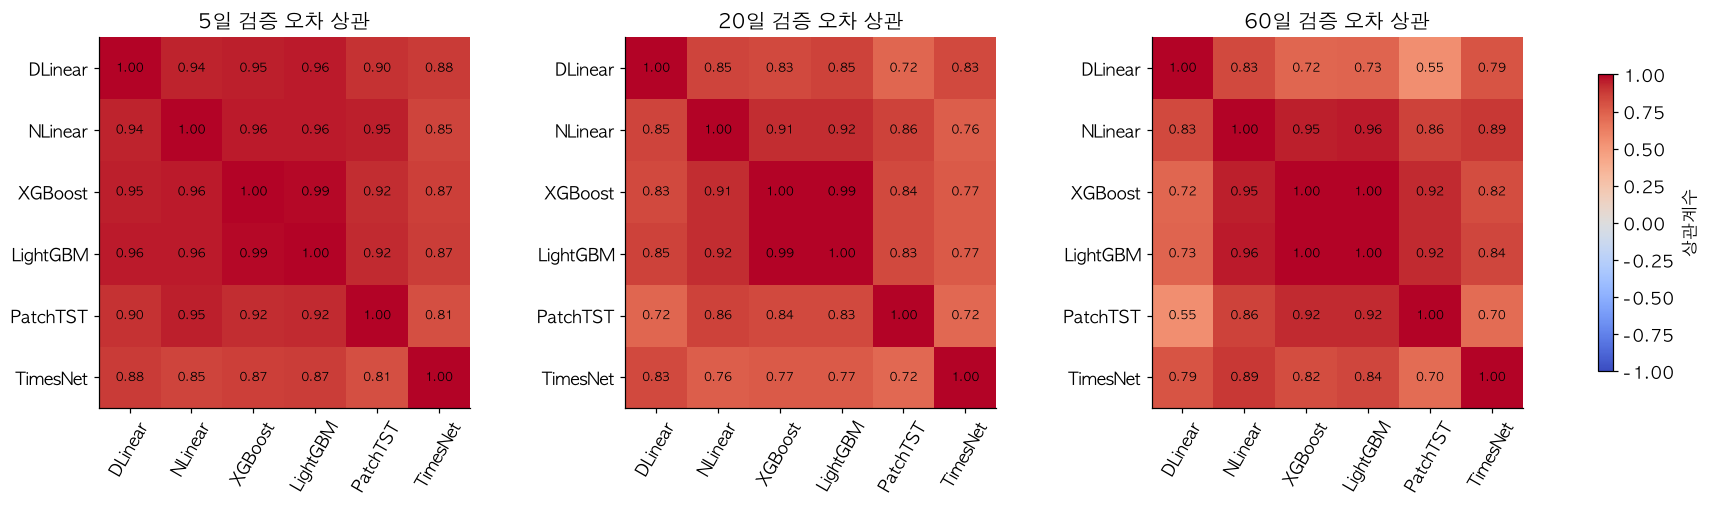

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)
for h, ax in zip(HORIZONS, axes):
    reference, forecasts = panels[("validation", h)]
    errors = forecasts[list(MODELS)].sub(reference.actual_return, axis=0)
    corr = errors.corr()
    im = ax.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
    ax.set(xticks=range(6), yticks=range(6), xticklabels=MODELS, yticklabels=MODELS,
           title=f"{h}일 검증 오차 상관")
    ax.tick_params(axis="x", rotation=60)
    for i in range(6):
        for j in range(6):
            ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=axes, label="상관계수", shrink=.8)
plt.show()

## 10. 뉴스 결합: 실제 감성분석과 제목 규칙을 구분

Jev의 `daily-200d-results.csv`는 **2026년 기사**라 기존 2022~2025년 예측과 공통 기간이 없다. 따라서 이 자료로 6개 모델 + LLM 감성분석의 성능을 검증했다고 주장하지 않는다. 아래에서 날짜·분석 완료 시점·겹치는 기준일 수를 직접 확인한다. 기사·분류가 없는 날짜를 임의로 중립 감성으로 대체하지 않는다.

과거 실험에는 기존 Daily Coffee News 제목의 `title-rules-v2`를 재사용한다. 이것은 **LLM/일반 감성분석이 아닌 희소한 규칙 신호**다. 기사 수정·발행 시점까지 확인하되 2026년 수집 자료의 과거 재구성이므로 당시 시스템에서 사용 가능했다는 뜻은 아니다. 실제 수집 시점까지 요구한 live 입력의 기사 수가 0인지 별도 계산한다. 결과는 연구용 가정이며 소스의 전수 수집 완전성을 보증하지 않는다.

가격 예측은 고정된 전체 6개 평균을 사용한다. 최근 **7달력일**의 기존 `news_weighted_impact_7d` 한 개만 추가한다. 예측은 해당 거래일 **23:00 UTC 이후**라는 가정이다. 당일 장 마감 전 예측 실험이 아니다.

`보정 로그수익률 = 전체 평균 로그수익률 + β × 뉴스 신호`로 정의한다. 절편 없이 `β ≥ 0`으로 뉴스 방향을 유지하며, 뉴스 신호가 0이면 가격도 그대로다. 2022년의 성숙한 정답으로 β를 적합하고 2023년에서 규제 강도 {0, 0.1, 1, 보정 없음}을 고른다. 최종 β는 2022~2023년으로 재적합한 뒤 2024~2025년에 고정 적용한다. λ는 신호 제곱합에 대한 상대 규제이며 `β=max(0, Σs·잔차 / ((1+λ)Σs²))`다. β가 0이 되는 결과도 그대로 보고한다.

기저 모델 설정이 2022~2023년 전체에서 선택됐으므로 2023년 뉴스 튜닝도 독립 평가가 아니다. 뉴스의 추가 효과는 같은 날짜의 **전체 평균 대비 변화**와 **Persistence 대비 변화**를 모두 확인한다. 뉴스 특성을 가격 모델에 다시 학습시키는 실험이나 LLM API 재호출은 포함하지 않는다.

학습 구간에 방향 신호가 하나도 없으면 β=0은 미식별 상태에서의 무보정 처리다. 이때 뉴스 추가 효과 0과 bootstrap [0, 0]은 동일 예측끼리 비교한 기계적 결과이며, 뉴스 효과가 없다는 통계적 증거가 아니다.

In [6]:
news_path = DATA / "news/articles.parquet"
if not news_path.exists():
    raise FileNotFoundError(f"과거 뉴스 입력을 찾을 수 없습니다: {news_path}")
articles = read_news(news_path)
news_sessions = pd.DatetimeIndex(sorted(selected_source.origin_date.unique()))
coverage = articles.attrs
if not {"coverage_start", "coverage_end"} <= set(coverage):
    raise ValueError("뉴스 수집 범위 메타데이터가 없어 결측과 빈 신호를 구분할 수 없습니다.")
assert pd.Timestamp(coverage["coverage_start"]) <= news_sessions.min() - pd.Timedelta(days=7)
assert pd.Timestamp(coverage["coverage_end"]) >= news_sessions.max()
news_features = aggregate_news(articles, news_sessions, windows=(7,))
live_news_features = aggregate_news(articles, news_sessions, windows=(7,),
                                   collected_bound=pd.Timestamp.now(tz="UTC"))
news_signal = news_features.news_weighted_impact_7d
news_hash = hashlib.sha256(news_path.read_bytes()).hexdigest()
print(f"제목 규칙 {ANALYSIS_VERSION}: {len(articles):,}건, 방향 기사 {articles.price_impact.ne('neutral').sum()}건")
print("과거 기준일의 실제 수집 시점 충족 기사 합계:", int(live_news_features.news_count_7d.sum()))
show_table(pd.DataFrame([{"연도": year, "기준일": len(group),
                         "기사 있는 날": int(group.news_count_7d.gt(0).sum()),
                         "방향 신호 있는 날": int(group.news_weighted_impact_7d.ne(0).sum())}
                        for year, group in news_features.groupby(news_features.index.year)]))
import json
jev_path = ROOT / "data/jev/sentiment.csv"
if jev_path.exists():
    jev = pd.read_csv(jev_path)
    jev = jev[jev.is_latest_analysis & jev.backfill_jobs.map(lambda x: "service" in json.loads(x))]
    published = pd.to_datetime(jev.published_at, utc=True, errors="raise")
    analyzed = pd.to_datetime(jev.analyzed_at, utc=True, errors="raise")
    dates_in_span = news_sessions[(news_sessions >= published.min().tz_localize(None).normalize()) &
                                 (news_sessions <= published.max().tz_localize(None).normalize())]
    show_table(pd.DataFrame([{"자료": "Jev 감성분석", "기사 수": len(jev),
        "기사 시작": str(published.min()), "기사 끝": str(published.max()),
        "최초 분석 완료": str(analyzed.min()), "기사 기간과 겹치는 예측 기준일": len(dates_in_span)}]))
    print("Jev 결합 평가 상태:", "공통 기간 없음 — 미검증" if len(dates_in_span)==0 else
          "공통 기간 존재 — 별도 as-of 조인·성숙 정답 평가 필요")
else:
    print("Jev 결합 평가 상태: 입력 파일 없음 — 미검증")

def fit_news_beta(reference, prediction, signal, cutoff, penalty):
    if not reference.index.equals(prediction.index) or not reference.index.equals(signal.index):
        raise ValueError("뉴스 보정 입력 날짜가 다릅니다.")
    if len(reference)==0 or reference.target_date.gt(pd.Timestamp(cutoff)).any():
        raise ValueError("보정 적합 시점에 아직 성숙하지 않은 정답이 있습니다.")
    if penalty < 0 or np.isnan(penalty):
        raise ValueError("규제 강도는 0 이상이어야 합니다.")
    s, residual = signal.to_numpy(float), (reference.actual_return-prediction).to_numpy(float)
    if not np.isfinite([s, residual]).all():
        raise ValueError("뉴스/잔차 결측을 0으로 채울 수 없습니다.")
    denominator = float(s @ s)
    if denominator == 0 or np.isinf(penalty):
        return 0.0
    return max(0.0, float(s @ residual) / ((1+penalty)*denominator))

news_tuning_rows, news_selected_rows = [], []
news_fit_status = {}
news_penalties = (np.inf, 1., .1, 0.)  # 같은 점수면 보정 없음/더 강한 규제를 먼저 선택한다.
for h in HORIZONS:
    reference, forecasts = panels[("validation", h)]
    signal = news_signal.reindex(reference.index)
    fit_mask, tune_mask = reference.index.year == 2022, reference.index.year == 2023
    assert fit_mask.any() and tune_mask.any()
    active_fit_days = int(signal.loc[fit_mask].ne(0).sum())
    news_fit_status[h] = ("2022 방향 신호 없음: 보정 효과 추정 불가" if active_fit_days == 0 else
                          f"2022 신호 {active_fit_days}일: 희소 표본의 탐색적 적합")
    candidates = []
    for penalty in news_penalties:
        beta = fit_news_beta(reference.loc[fit_mask], forecasts.loc[fit_mask, "전체 6개 평균"],
                             signal.loc[fit_mask], "2022-12-31", penalty)
        corrected = forecasts.loc[tune_mask, "전체 6개 평균"] + beta*signal.loc[tune_mask]
        row = {"지평": h, "규제": penalty, "2022 적합 β": beta,
               **metrics(reference.loc[tune_mask, "actual_return"], corrected, reference.loc[tune_mask, "current_price"])}
        candidates.append(row)
    news_tuning_rows.extend(candidates)
    chosen = min(candidates, key=lambda row: row["RMSE"])
    beta = fit_news_beta(reference, forecasts["전체 6개 평균"], signal, "2023-12-31", chosen["규제"])
    news_selected_rows.append({"지평": h, "규제": chosen["규제"], "최종 β": beta,
                              "적합 신호 날짜": int(signal.ne(0).sum()), "2023 튜닝 RMSE": chosen["RMSE"]})
    hist_reference, hist_forecasts = panels[("historical", h)]
    hist_signal = news_signal.reindex(hist_reference.index)
    assert hist_signal.notna().all()
    hist_forecasts["전체 평균 + 제목 규칙 뉴스"] = hist_forecasts["전체 6개 평균"] + beta*hist_signal
news_tuning_scores, news_selection = pd.DataFrame(news_tuning_rows), pd.DataFrame(news_selected_rows)
show_table(news_tuning_scores[["지평", "규제", "2022 적합 β", "RMSE", "Persistence 대비 개선 (%)"]])
show_table(news_selection.assign(자료_상태=news_selection["지평"].map(news_fit_status)))

제목 규칙 title-rules-v2: 7,548건, 방향 기사 32건
과거 기준일의 실제 수집 시점 충족 기사 합계: 0


|   연도 |   기준일 |   기사 있는 날 |   방향 신호 있는 날 |
|-------:|---------:|---------------:|--------------------:|
|   2022 |      246 |            245 |                   0 |
|   2023 |      245 |            245 |                   9 |
|   2024 |      252 |            252 |                  13 |
|   2025 |      246 |            246 |                  27 |

| 자료         |   기사 수 | 기사 시작                 | 기사 끝                   | 최초 분석 완료                   |   기사 기간과 겹치는 예측 기준일 |
|:-------------|----------:|:--------------------------|:--------------------------|:---------------------------------|---------------------------------:|
| Jev 감성분석 |        88 | 2026-03-13 12:51:18+00:00 | 2026-09-25 18:18:14+00:00 | 2026-09-26 09:12:42.298569+00:00 |                                0 |

Jev 결합 평가 상태: 공통 기간 없음 — 미검증


|     지평 |      규제 |   2022 적합 β |    RMSE |   Persistence 대비 개선 (%) |
|---------:|----------:|--------------:|--------:|----------------------------:|
|  5.00000 | inf       |       0.00000 | 0.04764 |                     0.03521 |
|  5.00000 |   1.00000 |       0.00000 | 0.04764 |                     0.03521 |
|  5.00000 |   0.10000 |       0.00000 | 0.04764 |                     0.03521 |
|  5.00000 |   0.00000 |       0.00000 | 0.04764 |                     0.03521 |
| 20.00000 | inf       |       0.00000 | 0.09965 |                   -10.83232 |
| 20.00000 |   1.00000 |       0.00000 | 0.09965 |                   -10.83232 |
| 20.00000 |   0.10000 |       0.00000 | 0.09965 |                   -10.83232 |
| 20.00000 |   0.00000 |       0.00000 | 0.09965 |                   -10.83232 |
| 60.00000 | inf       |       0.00000 | 0.17849 |                   -14.18001 |
| 60.00000 |   1.00000 |       0.00000 | 0.17849 |                   -14.18001 |
| 60.00000 |   0.10000 |       0.00000 | 0.17849 |                   -14.18001 |
| 60.00000 |   0.00000 |       0.00000 | 0.17849 |                   -14.18001 |

|   지평 |   규제 |   최종 β |   적합 신호 날짜 |   2023 튜닝 RMSE | 자료_상태                                |
|-------:|-------:|---------:|-----------------:|-----------------:|:-----------------------------------------|
|      5 |    inf |  0.00000 |                9 |          0.04764 | 2022 방향 신호 없음: 보정 효과 추정 불가 |
|     20 |    inf |  0.00000 |                9 |          0.09965 | 2022 방향 신호 없음: 보정 효과 추정 불가 |
|     60 |    inf |  0.00000 |                9 |          0.17849 | 2022 방향 신호 없음: 보정 효과 추정 불가 |

## 11. 고정한 조합의 과거 재평가와 불확실성

아래 표의 선택 앙상블은 검증으로 고정한 조합이다. 전체 평균과 뉴스 결합도 항상 함께 보고한다. 모든 조합의 사후 점수는 별도 표와 저장 결과에 남기되 그 최저값으로 선택하지 않는다.

중첩 수익률의 날짜를 독립 표본으로 취급하지 않기 위해, 같은 날짜의 두 손실을 함께 뽑는 **circular block bootstrap**을 사용한다(seed 42, 1,000회, 블록 h와 2h거래일). 비교값은 `비교 대상 MSE − 후보 MSE`이며 양수가 개선이다. 구간은 고정된 과거 예측에 대한 조건부 95% percentile 구간으로, 모델 재학습·후보 탐색의 불확실성이나 다중 비교를 보정한 유의성 검정이 아니다. 블록 길이 하나가 의존성을 모두 제거한다고 가정하지 않는다.

연도별 평가와 h거래일 간격의 비중첩 평가를 모든 시작 offset에서 반복한다. 비중첩 표본이 적고 기간별 결과가 달라질 수 있다. 현재 연구 자료로 장기적인 Persistence 대체를 확정하려면 부족하며, 고정한 절차로 새 기간의 전향적 성능을 확인해야 한다.

[시간 블록 bootstrap](https://bashtage.github.io/arch/bootstrap/timeseries-bootstraps.html) 정의를 참고했으며 추가 패키지 설치 없이 NumPy로 계산한다.

In [7]:
def comparison_score(reference, predicted):
    result = metrics(reference.actual_return, predicted, reference.current_price)
    baseline_price_rmse = np.sqrt(np.mean((reference.current_price*np.expm1(reference.actual_return))**2))
    result["가격 RMSE 개선 (%)"] = 100*(1-result["가격 RMSE"]/baseline_price_rmse)
    return result

experiment_rows, ensemble_prediction_rows, yearly_rows, offset_rows = [], [], [], []
for h in HORIZONS:
    reference, forecasts = panels[("historical", h)]
    labels = {"Persistence": "Persistence", "검증 선택 앙상블": ensemble_choice[h],
              "전체 6개 평균": "전체 6개 평균", "전체 평균 + 제목 규칙 뉴스": "전체 평균 + 제목 규칙 뉴스"}
    for name in forecasts:
        experiment_rows.append({"지평": h, "후보": name, **comparison_score(reference, forecasts[name])})
        ensemble_prediction_rows.append(reference.assign(horizon=h, candidate=name, predicted_return=forecasts[name])
                                        .reset_index())
    for label, name in labels.items():
        for year in (2024, 2025):
            mask = reference.index.year == year
            yearly_rows.append({"지평": h, "후보": label, "실제 조합": name, "연도": year,
                                **comparison_score(reference.loc[mask], forecasts.loc[mask, name])})
        positions = coffee_sessions(reference.index.min(), reference.target_date.max()).get_indexer(reference.index)
        assert (positions >= 0).all()
        for offset in range(h):
            mask = positions % h == offset
            sub = reference.loc[mask]
            assert (sub.index[1:] >= sub.target_date.iloc[:-1].to_numpy()).all()
            offset_rows.append({"지평": h, "후보": label, "offset": offset,
                                **comparison_score(sub, forecasts.loc[mask, name])})
experiment_scores = pd.DataFrame(experiment_rows)
ensemble_predictions = pd.concat(ensemble_prediction_rows, ignore_index=True)
yearly_ensemble_scores, offset_scores = pd.DataFrame(yearly_rows), pd.DataFrame(offset_rows)
main_rows = []
for h in HORIZONS:
    table = experiment_scores.loc[experiment_scores["지평"].eq(h)].set_index("후보")
    for label, name in {"Persistence": "Persistence", "검증 선택 앙상블": ensemble_choice[h],
                        "전체 6개 평균": "전체 6개 평균", "전체 평균 + 제목 규칙 뉴스": "전체 평균 + 제목 규칙 뉴스"}.items():
        main_rows.append({"지평": h, "후보": label, "실제 조합": name, **table.loc[name].to_dict()})
main_scores = pd.DataFrame(main_rows)
show_table(main_scores[["지평", "후보", "실제 조합", "표본", "RMSE", "Persistence 대비 개선 (%)",
                        "가격 RMSE", "가격 RMSE 개선 (%)"]])
show_table(yearly_ensemble_scores[["지평", "후보", "연도", "표본", "RMSE", "Persistence 대비 개선 (%)"]])
show_table(offset_scores.groupby(["지평", "후보"], as_index=False).agg(
    최소_표본=("표본", "min"), 최대_표본=("표본", "max"),
    최소_개선=("Persistence 대비 개선 (%)", "min"), 중앙_개선=("Persistence 대비 개선 (%)", "median"),
    최대_개선=("Persistence 대비 개선 (%)", "max")))
# 사후 전체 표: 검증 선택을 변경하지 않으며 조합 이름 순으로 표시한다.
show_table(experiment_scores[["지평", "후보", "RMSE", "Persistence 대비 개선 (%)"]].sort_values(["지평", "후보"]))

|     지평 | 후보                       | 실제 조합                  |      표본 |    RMSE |   Persistence 대비 개선 (%) |   가격 RMSE |   가격 RMSE 개선 (%) |
|---------:|:---------------------------|:---------------------------|----------:|--------:|----------------------------:|------------:|---------------------:|
|  5.00000 | Persistence                | Persistence                | 498.00000 | 0.05444 |                     0.00000 |    17.57075 |              0.00000 |
|  5.00000 | 검증 선택 앙상블           | NLinear + TimesNet         | 498.00000 | 0.05751 |                    -5.64076 |    18.64027 |             -6.08693 |
|  5.00000 | 전체 6개 평균              | 전체 6개 평균              | 498.00000 | 0.05573 |                    -2.37353 |    18.11077 |             -3.07343 |
|  5.00000 | 전체 평균 + 제목 규칙 뉴스 | 전체 평균 + 제목 규칙 뉴스 | 498.00000 | 0.05573 |                    -2.37353 |    18.11077 |             -3.07343 |
| 20.00000 | Persistence                | Persistence                | 483.00000 | 0.11300 |                     0.00000 |    36.09749 |              0.00000 |
| 20.00000 | 검증 선택 앙상블           | NLinear + XGBoost          | 483.00000 | 0.11446 |                    -1.29044 |    36.66952 |             -1.58470 |
| 20.00000 | 전체 6개 평균              | 전체 6개 평균              | 483.00000 | 0.11138 |                     1.43633 |    36.12973 |             -0.08931 |
| 20.00000 | 전체 평균 + 제목 규칙 뉴스 | 전체 평균 + 제목 규칙 뉴스 | 483.00000 | 0.11138 |                     1.43633 |    36.12973 |             -0.08931 |
| 60.00000 | Persistence                | Persistence                | 443.00000 | 0.18576 |                     0.00000 |    58.83049 |              0.00000 |
| 60.00000 | 검증 선택 앙상블           | DLinear + XGBoost          | 443.00000 | 0.16240 |                    12.57457 |    52.87276 |             10.12695 |
| 60.00000 | 전체 6개 평균              | 전체 6개 평균              | 443.00000 | 0.15930 |                    14.24708 |    53.04689 |              9.83096 |
| 60.00000 | 전체 평균 + 제목 규칙 뉴스 | 전체 평균 + 제목 규칙 뉴스 | 443.00000 | 0.15930 |                    14.24708 |    53.04689 |              9.83096 |

|   지평 | 후보                       |   연도 |   표본 |    RMSE |   Persistence 대비 개선 (%) |
|-------:|:---------------------------|-------:|-------:|--------:|----------------------------:|
|      5 | Persistence                |   2024 |    252 | 0.04872 |                     0.00000 |
|      5 | Persistence                |   2025 |    246 | 0.05974 |                     0.00000 |
|      5 | 검증 선택 앙상블           |   2024 |    252 | 0.04960 |                    -1.81231 |
|      5 | 검증 선택 앙상블           |   2025 |    246 | 0.06462 |                    -8.17157 |
|      5 | 전체 6개 평균              |   2024 |    252 | 0.04794 |                     1.59188 |
|      5 | 전체 6개 평균              |   2025 |    246 | 0.06272 |                    -4.98950 |
|      5 | 전체 평균 + 제목 규칙 뉴스 |   2024 |    252 | 0.04794 |                     1.59188 |
|      5 | 전체 평균 + 제목 규칙 뉴스 |   2025 |    246 | 0.06272 |                    -4.98950 |
|     20 | Persistence                |   2024 |    252 | 0.09932 |                     0.00000 |
|     20 | Persistence                |   2025 |    231 | 0.12626 |                     0.00000 |
|     20 | 검증 선택 앙상블           |   2024 |    252 | 0.09719 |                     2.13860 |
|     20 | 검증 선택 앙상블           |   2025 |    231 | 0.13073 |                    -3.54100 |
|     20 | 전체 6개 평균              |   2024 |    252 | 0.08867 |                    10.71659 |
|     20 | 전체 6개 평균              |   2025 |    231 | 0.13176 |                    -4.36270 |
|     20 | 전체 평균 + 제목 규칙 뉴스 |   2024 |    252 | 0.08867 |                    10.71659 |
|     20 | 전체 평균 + 제목 규칙 뉴스 |   2025 |    231 | 0.13176 |                    -4.36270 |
|     60 | Persistence                |   2024 |    252 | 0.19113 |                     0.00000 |
|     60 | Persistence                |   2025 |    191 | 0.17843 |                     0.00000 |
|     60 | 검증 선택 앙상블           |   2024 |    252 | 0.17884 |                     6.43268 |
|     60 | 검증 선택 앙상블           |   2025 |    191 | 0.13775 |                    22.79697 |
|     60 | 전체 6개 평균              |   2024 |    252 | 0.15975 |                    16.41632 |
|     60 | 전체 6개 평균              |   2025 |    191 | 0.15869 |                    11.06372 |
|     60 | 전체 평균 + 제목 규칙 뉴스 |   2024 |    252 | 0.15975 |                    16.41632 |
|     60 | 전체 평균 + 제목 규칙 뉴스 |   2025 |    191 | 0.15869 |                    11.06372 |

|   지평 | 후보                       |   최소_표본 |   최대_표본 |   최소_개선 |   중앙_개선 |   최대_개선 |
|-------:|:---------------------------|------------:|------------:|------------:|------------:|------------:|
|      5 | Persistence                |          99 |         100 |     0.00000 |     0.00000 |     0.00000 |
|      5 | 검증 선택 앙상블           |          99 |         100 |    -8.61671 |    -4.96047 |    -4.30110 |
|      5 | 전체 6개 평균              |          99 |         100 |    -4.28238 |    -2.10364 |    -1.21584 |
|      5 | 전체 평균 + 제목 규칙 뉴스 |          99 |         100 |    -4.28238 |    -2.10364 |    -1.21584 |
|     20 | Persistence                |          24 |          25 |     0.00000 |     0.00000 |     0.00000 |
|     20 | 검증 선택 앙상블           |          24 |          25 |    -7.83389 |    -0.37999 |     2.15443 |
|     20 | 전체 6개 평균              |          24 |          25 |    -9.45516 |     2.00687 |     7.67624 |
|     20 | 전체 평균 + 제목 규칙 뉴스 |          24 |          25 |    -9.45516 |     2.00687 |     7.67624 |
|     60 | Persistence                |           7 |           8 |     0.00000 |     0.00000 |     0.00000 |
|     60 | 검증 선택 앙상블           |           7 |           8 |    -7.29647 |    14.67748 |    27.06052 |
|     60 | 전체 6개 평균              |           7 |           8 |    -0.96813 |    16.15182 |    21.03928 |
|     60 | 전체 평균 + 제목 규칙 뉴스 |           7 |           8 |    -0.96813 |    16.15182 |    21.03928 |

|   지평 | 후보                       |    RMSE |   Persistence 대비 개선 (%) |
|-------:|:---------------------------|--------:|----------------------------:|
|      5 | DLinear                    | 0.05574 |                    -2.38359 |
|      5 | DLinear + LightGBM         | 0.05590 |                    -2.68745 |
|      5 | DLinear + NLinear          | 0.05564 |                    -2.19231 |
|      5 | DLinear + PatchTST         | 0.05549 |                    -1.92418 |
|      5 | DLinear + TimesNet         | 0.05714 |                    -4.95597 |
|      5 | DLinear + XGBoost          | 0.05596 |                    -2.78717 |
|      5 | LightGBM                   | 0.05735 |                    -5.33305 |
|      5 | LightGBM + PatchTST        | 0.05606 |                    -2.97874 |
|      5 | LightGBM + TimesNet        | 0.05822 |                    -6.93144 |
|      5 | NLinear                    | 0.05585 |                    -2.57759 |
|      5 | NLinear + LightGBM         | 0.05589 |                    -2.65679 |
|      5 | NLinear + PatchTST         | 0.05538 |                    -1.73219 |
|      5 | NLinear + TimesNet         | 0.05751 |                    -5.64076 |
|      5 | NLinear + XGBoost          | 0.05594 |                    -2.75967 |
|      5 | PatchTST                   | 0.05654 |                    -3.85213 |
|      5 | PatchTST + TimesNet        | 0.05796 |                    -6.45599 |
|      5 | Persistence                | 0.05444 |                     0.00000 |
|      5 | TimesNet                   | 0.06395 |                   -17.46697 |
|      5 | XGBoost                    | 0.05743 |                    -5.48804 |
|      5 | XGBoost + LightGBM         | 0.05729 |                    -5.23790 |
|      5 | XGBoost + PatchTST         | 0.05611 |                    -3.06411 |
|      5 | XGBoost + TimesNet         | 0.05829 |                    -7.06130 |
|      5 | 전체 6개 평균              | 0.05573 |                    -2.37353 |
|      5 | 전체 평균 + 제목 규칙 뉴스 | 0.05573 |                    -2.37353 |
|     20 | DLinear                    | 0.11269 |                     0.27615 |
|     20 | DLinear + LightGBM         | 0.10986 |                     2.78600 |
|     20 | DLinear + NLinear          | 0.11332 |                    -0.27882 |
|     20 | DLinear + PatchTST         | 0.11336 |                    -0.31496 |
|     20 | DLinear + TimesNet         | 0.10905 |                     3.49864 |
|     20 | DLinear + XGBoost          | 0.11045 |                     2.26477 |
|     20 | LightGBM                   | 0.11251 |                     0.44019 |
|     20 | LightGBM + PatchTST        | 0.11793 |                    -4.35907 |
|     20 | LightGBM + TimesNet        | 0.11301 |                    -0.00469 |
|     20 | NLinear                    | 0.11851 |                    -4.87469 |
|     20 | NLinear + LightGBM         | 0.11401 |                    -0.89255 |
|     20 | NLinear + PatchTST         | 0.11939 |                    -5.64764 |
|     20 | NLinear + TimesNet         | 0.11463 |                    -1.43471 |
|     20 | NLinear + XGBoost          | 0.11446 |                    -1.29044 |
|     20 | PatchTST                   | 0.13067 |                   -15.63035 |
|     20 | PatchTST + TimesNet        | 0.12293 |                    -8.78463 |
|     20 | Persistence                | 0.11300 |                     0.00000 |
|     20 | TimesNet                   | 0.12504 |                   -10.64911 |
|     20 | XGBoost                    | 0.11287 |                     0.12254 |
|     20 | XGBoost + LightGBM         | 0.11247 |                     0.47432 |
|     20 | XGBoost + PatchTST         | 0.11828 |                    -4.66628 |
|     20 | XGBoost + TimesNet         | 0.11337 |                    -0.32186 |
|     20 | 전체 6개 평균              | 0.11138 |                     1.43633 |
|     20 | 전체 평균 + 제목 규칙 뉴스 | 0.11138 |                     1.43633 |
|     60 | DLinear                    | 0.16388 |                    11.78141 |
|     60 | DLinear + LightGBM         | 0.16221 |                    12.68111 |
|     60 | DLinear + NLinear          | 0.16521 |                    11.06415 |
|     60 | DLinear + PatchTST         | 0.15591 |                    16.07179 |
|     60 | DLinear + TimesNet         | 0.15551 |                    16.28403 |
|     60 | DLinear + XGBoost          | 0.16240 |                    12.57457 |
|     60 | LightGBM                   | 0.17910 |                     3.58720 |
|     60 | LightGBM + PatchTST        | 0.16530 |                    11.01445 |
|     60 | LightGBM + TimesNet        | 0.16413 |                    11.64225 |
|     60 | NLinear                    | 0.17292 |                     6.91070 |
|     60 | NLinear + LightGBM         | 0.17258 |                     7.09676 |
|     60 | NLinear + PatchTST         | 0.16363 |                    11.91135 |
|     60 | NLinear + TimesNet         | 0.16375 |                    11.85145 |
|     60 | NLinear + XGBoost          | 0.17267 |                     7.04496 |
|     60 | PatchTST                   | 0.16050 |                    13.59798 |
|     60 | PatchTST + TimesNet        | 0.15938 |                    14.20211 |
|     60 | Persistence                | 0.18576 |                     0.00000 |
|     60 | TimesNet                   | 0.17899 |                     3.64398 |
|     60 | XGBoost                    | 0.17847 |                     3.92354 |
|     60 | XGBoost + LightGBM         | 0.17863 |                     3.84066 |
|     60 | XGBoost + PatchTST         | 0.16536 |                    10.98231 |
|     60 | XGBoost + TimesNet         | 0.16503 |                    11.15797 |
|     60 | 전체 6개 평균              | 0.15930 |                    14.24708 |
|     60 | 전체 평균 + 제목 규칙 뉴스 | 0.15930 |                    14.24708 |

|   지평 | 비교             | 비교 대상     |   블록 |   평균 MSE 개선 |   95% 하한 |   95% 상한 |
|-------:|:-----------------|:--------------|-------:|----------------:|-----------:|-----------:|
|      5 | 검증 선택 앙상블 | Persistence   |      5 |      -0.0003438 | -0.0007348 |  0.0000228 |
|      5 | 검증 선택 앙상블 | Persistence   |     10 |      -0.0003438 | -0.0007711 |  0.0000391 |
|      5 | 전체 평균        | Persistence   |      5 |      -0.0001424 | -0.0003861 |  0.0000983 |
|      5 | 전체 평균        | Persistence   |     10 |      -0.0001424 | -0.0004250 |  0.0001414 |
|      5 | 뉴스 결합        | Persistence   |      5 |      -0.0001424 | -0.0003861 |  0.0000983 |
|      5 | 뉴스 결합        | Persistence   |     10 |      -0.0001424 | -0.0004250 |  0.0001414 |
|      5 | 뉴스 추가 효과   | 전체 6개 평균 |      5 |       0.0000000 |  0.0000000 |  0.0000000 |
|      5 | 뉴스 추가 효과   | 전체 6개 평균 |     10 |       0.0000000 |  0.0000000 |  0.0000000 |
|     20 | 검증 선택 앙상블 | Persistence   |     20 |      -0.0003317 | -0.0033677 |  0.0022278 |
|     20 | 검증 선택 앙상블 | Persistence   |     40 |      -0.0003317 | -0.0039216 |  0.0024121 |
|     20 | 전체 평균        | Persistence   |     20 |       0.0003642 | -0.0027412 |  0.0031261 |
|     20 | 전체 평균        | Persistence   |     40 |       0.0003642 | -0.0032468 |  0.0032950 |
|     20 | 뉴스 결합        | Persistence   |     20 |       0.0003642 | -0.0027412 |  0.0031261 |
|     20 | 뉴스 결합        | Persistence   |     40 |       0.0003642 | -0.0032468 |  0.0032950 |
|     20 | 뉴스 추가 효과   | 전체 6개 평균 |     20 |       0.0000000 |  0.0000000 |  0.0000000 |
|     20 | 뉴스 추가 효과   | 전체 6개 평균 |     40 |       0.0000000 |  0.0000000 |  0.0000000 |
|     60 | 검증 선택 앙상블 | Persistence   |     60 |       0.0081327 | -0.0027730 |  0.0165120 |
|     60 | 검증 선택 앙상블 | Persistence   |    120 |       0.0081327 | -0.0028194 |  0.0181920 |
|     60 | 전체 평균        | Persistence   |     60 |       0.0091322 |  0.0013077 |  0.0158559 |
|     60 | 전체 평균        | Persistence   |    120 |       0.0091322 |  0.0012691 |  0.0148906 |
|     60 | 뉴스 결합        | Persistence   |     60 |       0.0091322 |  0.0013077 |  0.0158559 |
|     60 | 뉴스 결합        | Persistence   |    120 |       0.0091322 |  0.0012691 |  0.0148906 |
|     60 | 뉴스 추가 효과   | 전체 6개 평균 |     60 |       0.0000000 |  0.0000000 |  0.0000000 |
|     60 | 뉴스 추가 효과   | 전체 6개 평균 |    120 |       0.0000000 |  0.0000000 |  0.0000000 |

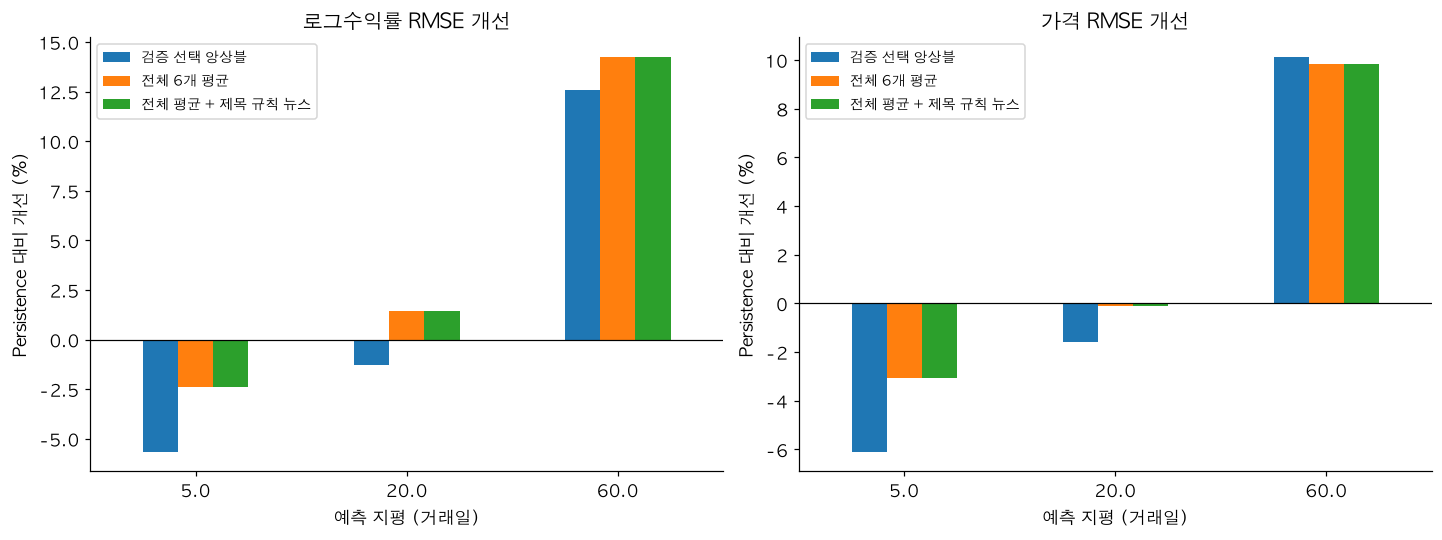

In [8]:
def paired_block_interval(actual, prediction, comparator, block, seed=42, repeats=1000):
    arrays = [np.asarray(x, dtype=float) for x in (actual, prediction, comparator)]
    if any(x.ndim != 1 or x.shape != arrays[0].shape for x in arrays) or not np.isfinite(arrays).all():
        raise ValueError("bootstrap 입력은 같은 길이의 유한 1차원 배열이어야 합니다.")
    n = len(arrays[0])
    if not 1 <= block <= n:
        raise ValueError("블록 길이가 표본 수 범위를 벗어났습니다.")
    y, pred, base = arrays
    gain = (y-base)**2 - (y-pred)**2
    rng = np.random.default_rng(seed)
    starts = rng.integers(0, n, size=(repeats, int(np.ceil(n/block))))
    indices = ((starts[..., None]+np.arange(block)) % n).reshape(repeats, -1)[:, :n]
    lo, hi = np.quantile(gain[indices].mean(axis=1), [.025, .975])
    return {"평균 MSE 개선": gain.mean(), "95% 하한": lo, "95% 상한": hi}

interval_rows = []
for h in HORIZONS:
    reference, forecasts = panels[("historical", h)]
    # 실제 거래일 축에 빠진 origin이 있으면 블록을 임의로 이어 붙이지 않는다.
    sessions = coffee_sessions(reference.index.min(), reference.index.max())
    pd.testing.assert_index_equal(reference.index.rename(None), sessions.rename(None))
    for label, name, baseline in (("검증 선택 앙상블", ensemble_choice[h], "Persistence"),
                                  ("전체 평균", "전체 6개 평균", "Persistence"),
                                  ("뉴스 결합", "전체 평균 + 제목 규칙 뉴스", "Persistence"),
                                  ("뉴스 추가 효과", "전체 평균 + 제목 규칙 뉴스", "전체 6개 평균")):
        for block in (h, 2*h):
            interval_rows.append({"지평": h, "비교": label, "비교 대상": baseline, "블록": block,
                **paired_block_interval(reference.actual_return, forecasts[name], forecasts[baseline], block)})
interval_scores = pd.DataFrame(interval_rows)
show_table(interval_scores, digits=7)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)
for ax, metric, title in zip(axes, ("Persistence 대비 개선 (%)", "가격 RMSE 개선 (%)"),
                            ("로그수익률 RMSE 개선", "가격 RMSE 개선")):
    pivot = main_scores.loc[main_scores["후보"].ne("Persistence")].pivot(index="지평", columns="후보", values=metric)
    pivot.plot.bar(ax=ax, rot=0)
    ax.axhline(0, color="black", linewidth=.8)
    ax.set(title=title, xlabel="예측 지평 (거래일)", ylabel="Persistence 대비 개선 (%)")
    ax.legend(fontsize=9)
plt.show()

## 12. 실행 검사·저장·결론

날짜 불일치, 성숙하지 않은 정답, 미래 기사, Persistence 혼입을 작은 예제로 검사한다. 아래 결과 파일은 원본 실행의 `ensemble_news_v1/` 하위에 별도로 저장한다. 기존 저장 함수의 임시 디렉터리·충돌 보존 정책을 재사용한다. 뉴스 소스/규칙 버전·원본 예측 hash·선택 구성·규제 강도를 결과 행에 기록해 입력을 추적한다. 같은 파일의 재저장은 동일 내용일 때만 허용한다.

In [9]:
# 산술 가격 평균과 구성원 제약 검사
probe = pd.DataFrame({"DLinear": np.log([1., 2.]), "NLinear": np.log([3., 4.])})
np.testing.assert_allclose(np.exp(price_mean_returns(probe, ("DLinear", "NLinear"))), [2., 3.])
for invalid in (("DLinear", "Persistence"), ("DLinear", "DLinear")):
    try:
        price_mean_returns(probe, invalid)
    except ValueError:
        pass
    else:
        raise AssertionError("Persistence/중복 구성원을 거부해야 합니다.")
# 날짜 하나가 빠져도 공통 평가 표본을 조용히 줄이지 않아야 한다.
probe_frame = selected_source.query("split == 'historical' and horizon == 5").copy()
probe_frame = probe_frame.drop(probe_frame.index[probe_frame.model.eq("NLinear")][0])
try:
    aligned_forecasts(probe_frame)
except AssertionError:
    pass
else:
    raise AssertionError("모델별 날짜 불일치가 검출되지 않았습니다.")
# 양의/음의 잔차·무신호·정답 성숙 검사
idx = pd.date_range("2022-01-01", periods=3)
r = pd.DataFrame({"actual_return": [1., 2., 3.], "target_date": idx+pd.Timedelta(days=5)}, index=idx)
s = pd.Series([1., 2., 3.], index=idx)
z = pd.Series(0., index=idx)
assert fit_news_beta(r, z, s, "2022-12-31", 0) == 1.
assert fit_news_beta(r, z, -s, "2022-12-31", 0) == 0.
assert fit_news_beta(r, z, z, "2022-12-31", 0) == 0.
assert fit_news_beta(r, z, s, "2022-12-31", np.inf) == 0.
try:
    fit_news_beta(r, z, s, "2022-01-02", 0)
except ValueError:
    pass
else:
    raise AssertionError("미성숙 정답이 적합에 유입됐습니다.")
# 미래 기사 제거가 과거 입력을 바꾸지 않는지 확인한다.
probe_dates = news_sessions[:3]
boundary = pd.Timestamp(probe_dates.max(), tz="UTC") + pd.Timedelta(hours=23)
earlier = articles.loc[articles.available_at.le(boundary) & articles.published_at.le(boundary)]
pd.testing.assert_frame_equal(aggregate_news(earlier, probe_dates, (7,)), news_features.loc[probe_dates])
zero_interval = paired_block_interval([1., 2., 3.], [0., 0., 0.], [0., 0., 0.], 2)
assert all(value == 0 for value in zero_interval.values())
assert not ensemble_predictions.duplicated(["horizon", "candidate", "origin_date"]).any()
assert np.isfinite(ensemble_predictions.predicted_return).all()
for row in experiment_scores.to_dict("records"):
    sub = ensemble_predictions.loc[(ensemble_predictions.horizon==row["지평"]) &
                                   (ensemble_predictions.candidate==row["후보"])]
    np.testing.assert_allclose(metrics(sub.actual_return, sub.predicted_return, sub.current_price)["RMSE"], row["RMSE"])
assert all("Persistence" not in ENSEMBLES[name] for name in ensemble_choice.values())
print("검사 통과: 평균 단위·구성원·공통 날짜·뉴스 방향/무신호·성숙 정답·미래 기사·지표 재계산")

ensemble_predictions["source_sha256"] = ensemble_source_hash
ensemble_predictions["news_sha256"] = news_hash
ensemble_predictions["news_analysis_version"] = ANALYSIS_VERSION
ensemble_predictions["selected_ensemble"] = ensemble_predictions.horizon.map(ensemble_choice)
ensemble_predictions["news_penalty"] = ensemble_predictions.horizon.map(news_selection.set_index("지평")["규제"])
ensemble_predictions["news_beta"] = ensemble_predictions.horizon.map(news_selection.set_index("지평")["최종 β"])
ensemble_predictions["news_signal"] = ensemble_predictions.origin_date.map(news_signal)
ensemble_predictions["news_mode"] = "retrospective_title_rules_7d_23UTC"
# 기존 저장 계약의 metrics 파일에 구분 열을 붙여 검증·선택·구간 추정도 함께 보관한다.
result_tables = pd.concat([experiment_scores.assign(표="과거 전체"), ensemble_validation_scores.assign(표="앙상블 검증"),
                          news_tuning_scores.assign(표="뉴스 튜닝"), news_selection.assign(표="뉴스 선택"),
                          interval_scores.assign(표="블록 구간")], ignore_index=True)
EXTENSION_OUTPUT = ENSEMBLE_SOURCE / "ensemble_news_v1"
save_results(EXTENSION_OUTPUT, ensemble_predictions, result_tables, yearly_ensemble_scores, offset_scores)
print("저장:", EXTENSION_OUTPUT.relative_to(ROOT))
for h in HORIZONS:
    rows = main_scores.loc[main_scores["지평"].eq(h)].set_index("후보")
    chosen = rows.loc["검증 선택 앙상블"]
    base, news = rows.loc["전체 6개 평균"], rows.loc["전체 평균 + 제목 규칙 뉴스"]
    gain = 100*(1-news["RMSE"]/base["RMSE"])
    display(Markdown(f"- **{h}일**: 검증 선택 `{ensemble_choice[h]}`의 RMSE **{chosen['RMSE']:.6f}**, "
                     f"Persistence 대비 **{chosen['Persistence 대비 개선 (%)']:+.2f}%**, "
                     f"가격 RMSE 기준 **{chosen['가격 RMSE 개선 (%)']:+.2f}%**. "
                     f"제목 규칙 뉴스의 전체 평균 대비 추가 개선은 **{gain:+.2f}%**다. "
                     f"뉴스 자료 상태: **{news_fit_status[h]}**."))
sixty_all = main_scores.loc[(main_scores["지평"]==60) & main_scores["후보"].eq("전체 6개 평균")].iloc[0]
sixty_intervals = interval_scores.loc[(interval_scores["지평"]==60) & interval_scores["비교"].eq("전체 평균")]
if sixty_all["Persistence 대비 개선 (%)"] > 0 and sixty_intervals["95% 하한"].gt(0).all():
    display(Markdown("**60일 전체 평균:** 두 블록 길이의 조건부 MSE 개선 구간이 0보다 크다. "
                     "이는 이번 과거 표본에서의 개선 근거이지만, 이미 본 기간·선택 과정·단일 seed 한계를 없애지는 않는다."))
display(Markdown("**판단:** 로그수익률과 가격의 개선을 구분하고 연도·비중첩·블록 길이 결과를 함께 본다. "
                 "0을 포함하는 구간으로 안정적 개선을 확정하지 않는다. 이 실험은 제한된 후보·단일 seed·이미 본 과거 자료의 비교다. "
                 "Jev 감성분석 결합은 공통 평가 자료를 확보하기 전까지 미검증이며, 제목 규칙 결과로 대신 주장하지 않는다. "
                 "후속 실험은 선택 절차를 고정해 새 기간의 여섯 모델 예측과 뉴스 분석 완료 시점을 함께 저장하고, "
                 "5/20/60일 정답이 성숙한 공통 날짜에서 평가한다."))

검사 통과: 평균 단위·구성원·공통 날짜·뉴스 방향/무신호·성숙 정답·미래 기사·지표 재계산
저장: data/processed/single_model_comparison/20260926T115735770501Z/ensemble_news_v1


- **5일**: 검증 선택 `NLinear + TimesNet`의 RMSE **0.057513**, Persistence 대비 **-5.64%**, 가격 RMSE 기준 **-6.09%**. 제목 규칙 뉴스의 전체 평균 대비 추가 개선은 **+0.00%**다. 뉴스 자료 상태: **2022 방향 신호 없음: 보정 효과 추정 불가**.

- **20일**: 검증 선택 `NLinear + XGBoost`의 RMSE **0.114463**, Persistence 대비 **-1.29%**, 가격 RMSE 기준 **-1.58%**. 제목 규칙 뉴스의 전체 평균 대비 추가 개선은 **+0.00%**다. 뉴스 자료 상태: **2022 방향 신호 없음: 보정 효과 추정 불가**.

- **60일**: 검증 선택 `DLinear + XGBoost`의 RMSE **0.162403**, Persistence 대비 **+12.57%**, 가격 RMSE 기준 **+10.13%**. 제목 규칙 뉴스의 전체 평균 대비 추가 개선은 **+0.00%**다. 뉴스 자료 상태: **2022 방향 신호 없음: 보정 효과 추정 불가**.

**60일 전체 평균:** 두 블록 길이의 조건부 MSE 개선 구간이 0보다 크다. 이는 이번 과거 표본에서의 개선 근거이지만, 이미 본 기간·선택 과정·단일 seed 한계를 없애지는 않는다.

**판단:** 로그수익률과 가격의 개선을 구분하고 연도·비중첩·블록 길이 결과를 함께 본다. 0을 포함하는 구간으로 안정적 개선을 확정하지 않는다. 이 실험은 제한된 후보·단일 seed·이미 본 과거 자료의 비교다. Jev 감성분석 결합은 공통 평가 자료를 확보하기 전까지 미검증이며, 제목 규칙 결과로 대신 주장하지 않는다. 후속 실험은 선택 절차를 고정해 새 기간의 여섯 모델 예측과 뉴스 분석 완료 시점을 함께 저장하고, 5/20/60일 정답이 성숙한 공통 날짜에서 평가한다.

## 13. 가격 방향: 매수 시점에 필요한 정보인가?

**평가 범위:** 기존 가격·기후·거시 모델의 저장 예측을 재사용한다. 5거래일은 약 1주, 20거래일은 약 1개월, 60거래일은 약 3개월이다. 각 지평의 `P[t+h]`와 기준일 `P[t]`를 비교하며, 예측값끼리의 전일 대비 변화가 아니다. 이미 확인한 2024~2025년 과거 재평가다. 모델 설정과 쌍 앙상블은 앞 절의 검증 RMSE 선택을 유지하고 방향 성능으로 재선택하지 않는다.

- **방향 적중률:** `sign(실제 로그수익률) == sign(예측 로그수익률)`의 비율. 정확한 0은 보합이다. Persistence의 0은 방향 신호 없음이며 50% 동전 던지기와 다르다.
- **균형 정확도:** `(상승 재현율 + 하락 재현율) / 2`. 실제 보합은 두 재현율의 분모에서 제외하며, 한 방향의 실제 표본이 없으면 결측이다. 무신호 예측은 실제 상승/하락에서 실패로 센다.
- **상승 정밀도:** 상승 예측 중 실제 상승 비율. **상승 누락률:** 실제 상승 중 상승을 예측하지 못한 비율. 전자는 불필요한 선매수, 후자는 가격 상승 전에 매수할 기회를 놓치는 위험을 살피는 지표다. 비용 자체를 측정하지는 않는다.
- 항상 상승·항상 하락 기준을 함께 표시한다. 예측은 확률이 아니므로 정밀도를 개별 날짜의 상승 확률로 해석하지 않는다.

표본수·연도별 결과·비중첩 평가와 circular block bootstrap을 함께 확인한다. 기존 31셀의 소스·출력은 보존했으며 이번에는 기존 완료 run의 예측으로 새 평가 셀만 실행했다. 전체 재학습은 반복하지 않았다.

In [6]:
def direction_metrics(actual, predicted):
    actual, predicted = np.asarray(actual, dtype=float), np.asarray(predicted, dtype=float)
    if actual.ndim != 1 or actual.shape != predicted.shape or not len(actual) or not np.isfinite([actual, predicted]).all():
        raise ValueError("방향 지표는 같은 길이의 비어 있지 않은 유한 1차원 배열이 필요합니다.")
    y, p = np.sign(actual), np.sign(predicted)
    up, down = y > 0, y < 0
    up_recall = np.mean(p[up] > 0) if up.any() else np.nan
    down_recall = np.mean(p[down] < 0) if down.any() else np.nan
    return {"표본": len(y), "실제 상승 수": int(up.sum()), "실제 하락 수": int(down.sum()),
            "실제 보합 수": int((y == 0).sum()), "상승 예측 수": int((p > 0).sum()),
            "실제 상승 (%)": 100*up.mean(), "방향 신호 (%)": 100*np.mean(p != 0),
            "방향 적중률 (%)": 100*np.mean(y == p),
            "균형 정확도 (%)": 50*(up_recall+down_recall),
            "상승 정밀도 (%)": 100*np.mean(y[p > 0] > 0) if (p > 0).any() else np.nan,
            "상승 재현율 (%)": 100*up_recall, "하락 재현율 (%)": 100*down_recall,
            "상승 누락률 (%)": 100*(1-up_recall)}

DIRECTION_MODELS = (*MODELS, "전체 6개 평균", "검증 RMSE 선택 쌍", "Persistence")
direction_panels, direction_rows, direction_prediction_rows = {}, [], []
for h in HORIZONS:
    reference, forecasts = panels[("historical", h)]
    names = {name: name for name in (*MODELS, "전체 6개 평균", "Persistence")}
    names["검증 RMSE 선택 쌍"] = ensemble_choice[h]
    predictions = forecasts.loc[:, list(names.values())].copy()
    predictions.columns = list(names)
    direction_panels[h] = (reference, predictions)
    for name in DIRECTION_MODELS:
        result = direction_metrics(reference.actual_return, predictions[name])
        old = metrics(reference.actual_return, predictions[name], reference.current_price)
        np.testing.assert_allclose(result["방향 적중률 (%)"], old["방향 정확도 (%)"])
        np.testing.assert_allclose(result["균형 정확도 (%)"], old["방향 균형 정확도 (%)"])
        direction_rows.append({"지평": h, "모델": name, "실제 조합": names[name],
                               "가격 RMSE": old["가격 RMSE"], **result})
        direction_prediction_rows.append(reference.assign(horizon=h, candidate=name,
            predicted_return=predictions[name], source_sha256=ensemble_source_hash).reset_index())
    for name, sign in (("항상 상승", 1), ("항상 하락", -1)):
        direction_rows.append({"지평": h, "모델": name, "실제 조합": name,
                               "가격 RMSE": np.nan,
                               **direction_metrics(reference.actual_return, np.full(len(reference), sign))})
direction_scores = pd.DataFrame(direction_rows)
direction_predictions = pd.concat(direction_prediction_rows, ignore_index=True)
for h in HORIZONS:
    display(Markdown(f"### {h}거래일 방향 비교"))
    show_table(direction_scores.loc[direction_scores["지평"].eq(h), ["모델", "표본", "실제 상승 (%)",
        "방향 적중률 (%)", "균형 정확도 (%)", "상승 정밀도 (%)", "상승 누락률 (%)", "하락 재현율 (%)"]], digits=2)
print("검증 RMSE 선택 쌍:", ensemble_choice)
print("자료:", ENSEMBLE_SOURCE.relative_to(ROOT), "SHA256:", ensemble_source_hash)

### 5거래일 방향 비교

| 모델              |   표본 |   실제 상승 (%) |   방향 적중률 (%) |   균형 정확도 (%) |   상승 정밀도 (%) |   상승 누락률 (%) |   하락 재현율 (%) |
|:------------------|-------:|----------------:|------------------:|------------------:|------------------:|------------------:|------------------:|
| DLinear           |    498 |           54.82 |             52.41 |             51.87 |             56.25 |             40.66 |             44.39 |
| NLinear           |    498 |           54.82 |             51.41 |             51.86 |             56.72 |             50.55 |             54.26 |
| XGBoost           |    498 |           54.82 |             51.00 |             49.31 |             54.39 |             31.87 |             30.49 |
| LightGBM          |    498 |           54.82 |             51.41 |             50.01 |             55.05 |             34.07 |             34.08 |
| PatchTST          |    498 |           54.82 |             48.19 |             47.12 |             52.41 |             40.29 |             34.53 |
| TimesNet          |    498 |           54.82 |             52.61 |             53.12 |             58.30 |             49.82 |             56.05 |
| 전체 6개 평균     |    498 |           54.82 |             52.01 |             51.67 |             56.32 |             42.86 |             46.19 |
| 검증 RMSE 선택 쌍 |    498 |           54.82 |             49.60 |             50.49 |             55.35 |             56.41 |             57.40 |
| Persistence       |    498 |           54.82 |              0.40 |              0.00 |            nan    |            100.00 |              0.00 |
| 항상 상승         |    498 |           54.82 |             54.82 |             50.00 |             54.82 |              0.00 |              0.00 |
| 항상 하락         |    498 |           54.82 |             44.78 |             50.00 |            nan    |            100.00 |            100.00 |

### 20거래일 방향 비교

| 모델              |   표본 |   실제 상승 (%) |   방향 적중률 (%) |   균형 정확도 (%) |   상승 정밀도 (%) |   상승 누락률 (%) |   하락 재현율 (%) |
|:------------------|-------:|----------------:|------------------:|------------------:|------------------:|------------------:|------------------:|
| DLinear           |    483 |           59.83 |             53.42 |             55.74 |             66.84 |             56.06 |             67.53 |
| NLinear           |    483 |           59.83 |             55.69 |             54.00 |             63.07 |             37.37 |             45.36 |
| XGBoost           |    483 |           59.83 |             58.59 |             59.64 |             69.78 |             45.67 |             64.95 |
| LightGBM          |    483 |           59.83 |             56.94 |             58.34 |             68.84 |             48.79 |             65.46 |
| PatchTST          |    483 |           59.83 |             50.10 |             49.07 |             59.02 |             45.67 |             43.81 |
| TimesNet          |    483 |           59.83 |             59.63 |             58.98 |             67.67 |             37.72 |             55.67 |
| 전체 6개 평균     |    483 |           59.83 |             60.87 |             61.37 |             70.83 |             41.18 |             63.92 |
| 검증 RMSE 선택 쌍 |    483 |           59.83 |             56.11 |             55.36 |             64.53 |             40.83 |             51.55 |
| Persistence       |    483 |           59.83 |              0.00 |              0.00 |            nan    |            100.00 |              0.00 |
| 항상 상승         |    483 |           59.83 |             59.83 |             50.00 |             59.83 |              0.00 |              0.00 |
| 항상 하락         |    483 |           59.83 |             40.17 |             50.00 |            nan    |            100.00 |            100.00 |

### 60거래일 방향 비교

| 모델              |   표본 |   실제 상승 (%) |   방향 적중률 (%) |   균형 정확도 (%) |   상승 정밀도 (%) |   상승 누락률 (%) |   하락 재현율 (%) |
|:------------------|-------:|----------------:|------------------:|------------------:|------------------:|------------------:|------------------:|
| DLinear           |    443 |           79.01 |             81.94 |             85.02 |             96.88 |             20.29 |             90.32 |
| NLinear           |    443 |           79.01 |             68.85 |             71.60 |             91.41 |             33.14 |             76.34 |
| XGBoost           |    443 |           79.01 |             59.37 |             64.81 |             88.99 |             44.57 |             74.19 |
| LightGBM          |    443 |           79.01 |             62.30 |             69.43 |             92.17 |             42.86 |             81.72 |
| PatchTST          |    443 |           79.01 |             63.88 |             47.14 |             77.78 |             24.00 |             18.28 |
| TimesNet          |    443 |           79.01 |             62.75 |             43.27 |             76.20 |             23.14 |              9.68 |
| 전체 6개 평균     |    443 |           79.01 |             74.49 |             69.25 |             88.10 |             21.71 |             60.22 |
| 검증 RMSE 선택 쌍 |    443 |           79.01 |             74.49 |             79.51 |             95.75 |             29.14 |             88.17 |
| Persistence       |    443 |           79.01 |              0.00 |              0.00 |            nan    |            100.00 |              0.00 |
| 항상 상승         |    443 |           79.01 |             79.01 |             50.00 |             79.01 |              0.00 |              0.00 |
| 항상 하락         |    443 |           79.01 |             20.99 |             50.00 |            nan    |            100.00 |            100.00 |

검증 RMSE 선택 쌍: {5: 'NLinear + TimesNet', 20: 'NLinear + XGBoost', 60: 'DLinear + XGBoost'}
자료: data/processed/single_model_comparison/20260926T115735770501Z SHA256: 35035873ee7b3818d21180ffc7530362b2723740d649ad9cda8d23182f4e38e8


### 13.1 연도·중첩·불확실성

95% 구간은 저장 예측을 고정한 조건부 percentile 구간이다(1,000회, seed 42, 블록 h·2h). 같은 표본을 뽑아 **항상 상승 대비 적중률 차이(pp)**와 균형 정확도를 계산한다. 균형 정확도는 두 실제 방향이 모두 있는 반복에서만 계산하고 유효 반복 수를 남긴다. 모델 선택·재학습·다중 비교 불확실성은 포함하지 않는다. 비중첩 표본은 실제 거래일 축의 모든 offset을 사용하며 60일은 offset당 7~8건에 불과하다. 지평마다 성숙한 목표일 수가 달라 직접 순위 비교에 주의한다.

In [7]:
def direction_block_interval(actual, predicted, block, seed=42, repeats=1000):
    direction_metrics(actual, predicted)  # 입력 검증을 공유한다.
    y, p = np.sign(np.asarray(actual)), np.sign(np.asarray(predicted))
    n = len(y)
    if not isinstance(block, (int, np.integer)) or not 1 <= block <= n or repeats < 1:
        raise ValueError("유효한 블록 길이와 반복 수가 필요합니다.")
    starts = np.random.default_rng(seed).integers(0, n, size=(repeats, int(np.ceil(n/block))))
    indices = ((starts[..., None]+np.arange(block)) % n).reshape(repeats, -1)[:, :n]
    by, bp = y[indices], p[indices]
    delta = 100*((by == bp).mean(axis=1)-(by > 0).mean(axis=1))
    up_n, down_n = (by > 0).sum(axis=1), (by < 0).sum(axis=1)
    valid = (up_n > 0) & (down_n > 0)
    balanced = 50*(((by[valid] > 0) & (bp[valid] > 0)).sum(axis=1)/up_n[valid]
                  + ((by[valid] < 0) & (bp[valid] < 0)).sum(axis=1)/down_n[valid])
    lo, hi = np.quantile(balanced, [.025, .975]) if valid.any() else (np.nan, np.nan)
    d_lo, d_hi = np.quantile(delta, [.025, .975])
    return {"균형 95% 하한": lo, "균형 95% 상한": hi, "균형 유효 반복": int(valid.sum()),
            "항상 상승 대비 적중률 차이 (pp)": 100*((y == p).mean()-(y > 0).mean()),
            "차이 95% 하한": d_lo, "차이 95% 상한": d_hi}

direction_yearly, direction_offsets, direction_intervals = [], [], []
for h, (reference, predictions) in direction_panels.items():
    pd.testing.assert_index_equal(reference.index.rename(None),
                                  coffee_sessions(reference.index.min(), reference.index.max()).rename(None))
    positions = coffee_sessions(reference.index.min(), reference.target_date.max()).get_indexer(reference.index)
    assert (positions >= 0).all()
    for name in DIRECTION_MODELS:
        for year in (2024, 2025):
            mask = reference.index.year == year
            direction_yearly.append({"지평": h, "모델": name, "연도": year,
                **direction_metrics(reference.actual_return.loc[mask], predictions.loc[mask, name])})
        for offset in range(h):
            mask = positions % h == offset
            sub = reference.loc[mask]
            assert (sub.index[1:] >= sub.target_date.iloc[:-1].to_numpy()).all()
            direction_offsets.append({"지평": h, "모델": name, "offset": offset,
                **direction_metrics(sub.actual_return, predictions.loc[mask, name])})
        for block in (h, 2*h):
            direction_intervals.append({"지평": h, "모델": name, "블록": block,
                **direction_block_interval(reference.actual_return, predictions[name], block)})
direction_yearly = pd.DataFrame(direction_yearly)
direction_offsets = pd.DataFrame(direction_offsets)
direction_intervals = pd.DataFrame(direction_intervals)
show_table(direction_yearly.pivot(index=["지평", "모델"], columns="연도",
                                  values="균형 정확도 (%)").reset_index(), digits=2)
show_table(direction_offsets.groupby(["지평", "모델"], as_index=False).agg(
    최소_표본=("표본", "min"), 최대_표본=("표본", "max"), 균형_유효_offset=("균형 정확도 (%)", "count"),
    균형_최소=("균형 정확도 (%)", "min"), 균형_중앙=("균형 정확도 (%)", "median"),
    균형_최대=("균형 정확도 (%)", "max")), digits=2)
show_table(direction_intervals, digits=2)

|   지평 | 모델              |   2024 |   2025 |
|-------:|:------------------|-------:|-------:|
|      5 | DLinear           |  53.80 |  48.84 |
|      5 | LightGBM          |  54.34 |  43.52 |
|      5 | NLinear           |  49.30 |  52.43 |
|      5 | PatchTST          |  49.55 |  43.67 |
|      5 | Persistence       |   0.00 |   0.00 |
|      5 | TimesNet          |  52.82 |  52.49 |
|      5 | XGBoost           |  55.45 |  40.95 |
|      5 | 검증 RMSE 선택 쌍 |  52.31 |  46.82 |
|      5 | 전체 6개 평균     |  54.18 |  47.17 |
|     20 | DLinear           |  43.66 |  58.35 |
|     20 | LightGBM          |  48.59 |  56.12 |
|     20 | NLinear           |  41.64 |  57.19 |
|     20 | PatchTST          |  56.91 |  39.83 |
|     20 | Persistence       |   0.00 |   0.00 |
|     20 | TimesNet          |  64.83 |  49.01 |
|     20 | XGBoost           |  46.84 |  59.13 |
|     20 | 검증 RMSE 선택 쌍 |  43.01 |  56.78 |
|     20 | 전체 6개 평균     |  48.77 |  62.48 |
|     60 | DLinear           |  51.50 |  83.08 |
|     60 | LightGBM          |  50.16 |  66.80 |
|     60 | NLinear           |  66.23 |  65.34 |
|     60 | PatchTST          |  56.44 |  50.27 |
|     60 | Persistence       |   0.00 |   0.00 |
|     60 | TimesNet          |  52.91 |  32.22 |
|     60 | XGBoost           |  59.55 |  60.80 |
|     60 | 검증 RMSE 선택 쌍 |  46.64 |  78.55 |
|     60 | 전체 6개 평균     |  50.28 |  67.66 |

|   지평 | 모델              |   최소_표본 |   최대_표본 |   균형_유효_offset |   균형_최소 |   균형_중앙 |   균형_최대 |
|-------:|:------------------|------------:|------------:|-------------------:|------------:|------------:|------------:|
|      5 | DLinear           |          99 |         100 |                  5 |       48.61 |       52.73 |       55.78 |
|      5 | LightGBM          |          99 |         100 |                  5 |       46.10 |       49.66 |       54.09 |
|      5 | NLinear           |          99 |         100 |                  5 |       48.80 |       50.68 |       56.02 |
|      5 | PatchTST          |          99 |         100 |                  5 |       43.96 |       47.74 |       49.32 |
|      5 | Persistence       |          99 |         100 |                  5 |        0.00 |        0.00 |        0.00 |
|      5 | TimesNet          |          99 |         100 |                  5 |       50.85 |       53.64 |       55.04 |
|      5 | XGBoost           |          99 |         100 |                  5 |       43.42 |       51.36 |       53.64 |
|      5 | 검증 RMSE 선택 쌍 |          99 |         100 |                  5 |       46.66 |       49.77 |       56.14 |
|      5 | 전체 6개 평균     |          99 |         100 |                  5 |       45.04 |       52.73 |       55.23 |
|     20 | DLinear           |          24 |          25 |                 20 |       43.40 |       55.62 |       67.13 |
|     20 | LightGBM          |          24 |          25 |                 20 |       40.97 |       59.17 |       79.41 |
|     20 | NLinear           |          24 |          25 |                 20 |       43.70 |       52.81 |       63.87 |
|     20 | PatchTST          |          24 |          25 |                 20 |       31.43 |       50.00 |       66.67 |
|     20 | Persistence       |          24 |          25 |                 20 |        0.00 |        0.00 |        0.00 |
|     20 | TimesNet          |          24 |          25 |                 20 |       44.79 |       58.31 |       70.83 |
|     20 | XGBoost           |          24 |          25 |                 20 |       40.97 |       58.45 |       75.21 |
|     20 | 검증 RMSE 선택 쌍 |          24 |          25 |                 20 |       46.88 |       55.65 |       66.67 |
|     20 | 전체 6개 평균     |          24 |          25 |                 20 |       46.88 |       62.34 |       72.27 |
|     60 | DLinear           |           7 |           8 |                 60 |       58.33 |       90.83 |      100.00 |
|     60 | LightGBM          |           7 |           8 |                 60 |       16.67 |       76.79 |       91.67 |
|     60 | NLinear           |           7 |           8 |                 60 |       16.67 |       80.95 |      100.00 |
|     60 | PatchTST          |           7 |           8 |                 60 |       30.00 |       35.71 |      100.00 |
|     60 | Persistence       |           7 |           8 |                 60 |        0.00 |        0.00 |        0.00 |
|     60 | TimesNet          |           7 |           8 |                 60 |       25.00 |       35.71 |       75.00 |
|     60 | XGBoost           |           7 |           8 |                 60 |       25.00 |       70.00 |       91.67 |
|     60 | 검증 RMSE 선택 쌍 |           7 |           8 |                 60 |       58.33 |       81.67 |       91.67 |
|     60 | 전체 6개 평균     |           7 |           8 |                 60 |       33.33 |       83.33 |      100.00 |

|   지평 | 모델              |   블록 |   균형 95% 하한 |   균형 95% 상한 |   균형 유효 반복 |   항상 상승 대비 적중률 차이 (pp) |   차이 95% 하한 |   차이 95% 상한 |
|-------:|:------------------|-------:|----------------:|----------------:|-----------------:|----------------------------------:|----------------:|----------------:|
|      5 | DLinear           |      5 |           45.27 |           58.48 |             1000 |                             -2.41 |          -11.45 |            6.64 |
|      5 | DLinear           |     10 |           45.27 |           59.05 |             1000 |                             -2.41 |          -11.65 |            7.23 |
|      5 | NLinear           |      5 |           45.09 |           58.22 |             1000 |                             -3.41 |          -13.66 |            6.43 |
|      5 | NLinear           |     10 |           44.33 |           58.84 |             1000 |                             -3.41 |          -14.26 |            6.83 |
|      5 | XGBoost           |      5 |           43.79 |           55.09 |             1000 |                             -3.82 |          -11.65 |            3.21 |
|      5 | XGBoost           |     10 |           42.52 |           55.68 |             1000 |                             -3.82 |          -12.45 |            3.61 |
|      5 | LightGBM          |      5 |           44.02 |           55.91 |             1000 |                             -3.41 |          -11.85 |            4.42 |
|      5 | LightGBM          |     10 |           43.29 |           56.81 |             1000 |                             -3.41 |          -12.25 |            4.82 |
|      5 | PatchTST          |      5 |           40.91 |           53.68 |             1000 |                             -6.63 |          -15.26 |            1.41 |
|      5 | PatchTST          |     10 |           40.13 |           53.84 |             1000 |                             -6.63 |          -15.66 |            1.20 |
|      5 | TimesNet          |      5 |           46.42 |           59.46 |             1000 |                             -2.21 |          -12.65 |            7.63 |
|      5 | TimesNet          |     10 |           45.48 |           60.31 |             1000 |                             -2.21 |          -13.65 |            7.63 |
|      5 | 전체 6개 평균     |      5 |           44.85 |           58.55 |             1000 |                             -2.81 |          -12.45 |            5.43 |
|      5 | 전체 6개 평균     |     10 |           44.00 |           59.29 |             1000 |                             -2.81 |          -13.25 |            6.43 |
|      5 | 검증 RMSE 선택 쌍 |      5 |           44.14 |           56.85 |             1000 |                             -5.22 |          -15.66 |            4.82 |
|      5 | 검증 RMSE 선택 쌍 |     10 |           43.92 |           57.27 |             1000 |                             -5.22 |          -16.06 |            5.02 |
|      5 | Persistence       |      5 |            0.00 |            0.00 |             1000 |                            -54.42 |          -61.45 |          -47.59 |
|      5 | Persistence       |     10 |            0.00 |            0.00 |             1000 |                            -54.42 |          -62.45 |          -46.78 |
|     20 | DLinear           |     20 |           43.26 |           66.65 |             1000 |                             -6.42 |          -27.13 |           14.29 |
|     20 | DLinear           |     40 |           43.16 |           66.39 |             1000 |                             -6.42 |          -28.16 |           13.87 |
|     20 | NLinear           |     20 |           40.46 |           67.11 |             1000 |                             -4.14 |          -23.19 |           15.33 |
|     20 | NLinear           |     40 |           38.25 |           67.16 |             1000 |                             -4.14 |          -26.30 |           15.33 |
|     20 | XGBoost           |     20 |           48.79 |           69.85 |             1000 |                             -1.24 |          -21.12 |           18.22 |
|     20 | XGBoost           |     40 |           48.56 |           69.23 |             1000 |                             -1.24 |          -22.38 |           17.60 |
|     20 | LightGBM          |     20 |           48.26 |           67.96 |             1000 |                             -2.90 |          -23.61 |           16.78 |
|     20 | LightGBM          |     40 |           48.31 |           67.42 |             1000 |                             -2.90 |          -24.86 |           16.78 |
|     20 | PatchTST          |     20 |           38.32 |           59.60 |             1000 |                             -9.73 |          -26.09 |            4.97 |
|     20 | PatchTST          |     40 |           38.35 |           59.93 |             1000 |                             -9.73 |          -26.29 |            4.15 |
|     20 | TimesNet          |     20 |           46.80 |           70.52 |             1000 |                             -0.21 |          -16.15 |           14.08 |
|     20 | TimesNet          |     40 |           44.90 |           72.18 |             1000 |                             -0.21 |          -16.15 |           14.29 |
|     20 | 전체 6개 평균     |     20 |           49.08 |           72.43 |             1000 |                              1.04 |          -18.43 |           21.12 |
|     20 | 전체 6개 평균     |     40 |           48.84 |           71.73 |             1000 |                              1.04 |          -21.74 |           19.88 |
|     20 | 검증 RMSE 선택 쌍 |     20 |           42.31 |           67.76 |             1000 |                             -3.73 |          -23.81 |           16.56 |
|     20 | 검증 RMSE 선택 쌍 |     40 |           40.53 |           67.75 |             1000 |                             -3.73 |          -26.71 |           16.16 |
|     20 | Persistence       |     20 |            0.00 |            0.00 |             1000 |                            -59.83 |          -71.84 |          -47.62 |
|     20 | Persistence       |     40 |            0.00 |            0.00 |             1000 |                            -59.83 |          -71.01 |          -48.45 |
|     60 | DLinear           |     60 |           61.33 |           94.64 |             1000 |                              2.93 |          -27.31 |           32.73 |
|     60 | DLinear           |    120 |           59.23 |           93.86 |             1000 |                              2.93 |          -21.45 |           31.38 |
|     60 | NLinear           |     60 |           60.48 |           82.66 |             1000 |                            -10.16 |          -37.25 |           16.05 |
|     60 | NLinear           |    120 |           57.92 |           79.88 |             1000 |                            -10.16 |          -32.29 |           15.81 |
|     60 | XGBoost           |     60 |           48.65 |           76.67 |             1000 |                            -19.64 |          -49.44 |           10.61 |
|     60 | XGBoost           |    120 |           49.15 |           73.80 |             1000 |                            -19.64 |          -50.79 |           11.52 |
|     60 | LightGBM          |     60 |           43.57 |           82.60 |             1000 |                            -16.70 |          -49.44 |           15.80 |
|     60 | LightGBM          |    120 |           43.51 |           79.99 |             1000 |                            -16.70 |          -51.02 |           18.29 |
|     60 | PatchTST          |     60 |           37.17 |           59.14 |             1000 |                            -15.12 |          -34.77 |            1.35 |
|     60 | PatchTST          |    120 |           35.42 |           59.18 |             1000 |                            -15.12 |          -36.35 |            3.39 |
|     60 | TimesNet          |     60 |           34.83 |           55.83 |             1000 |                            -16.25 |          -30.02 |           -4.06 |
|     60 | TimesNet          |    120 |           33.04 |           56.47 |             1000 |                            -16.25 |          -24.15 |           -7.67 |
|     60 | 전체 6개 평균     |     60 |           51.53 |           81.32 |             1000 |                             -4.51 |          -29.57 |           16.26 |
|     60 | 전체 6개 평균     |    120 |           50.30 |           78.05 |             1000 |                             -4.51 |          -27.10 |           16.26 |
|     60 | 검증 RMSE 선택 쌍 |     60 |           55.61 |           90.76 |             1000 |                             -4.51 |          -35.22 |           26.42 |
|     60 | 검증 RMSE 선택 쌍 |    120 |           53.18 |           89.91 |             1000 |                             -4.51 |          -34.09 |           27.55 |
|     60 | Persistence       |     60 |            0.00 |            0.00 |             1000 |                            -79.01 |          -96.39 |          -55.98 |
|     60 | Persistence       |    120 |            0.00 |            0.00 |             1000 |                            -79.01 |          -97.29 |          -53.27 |

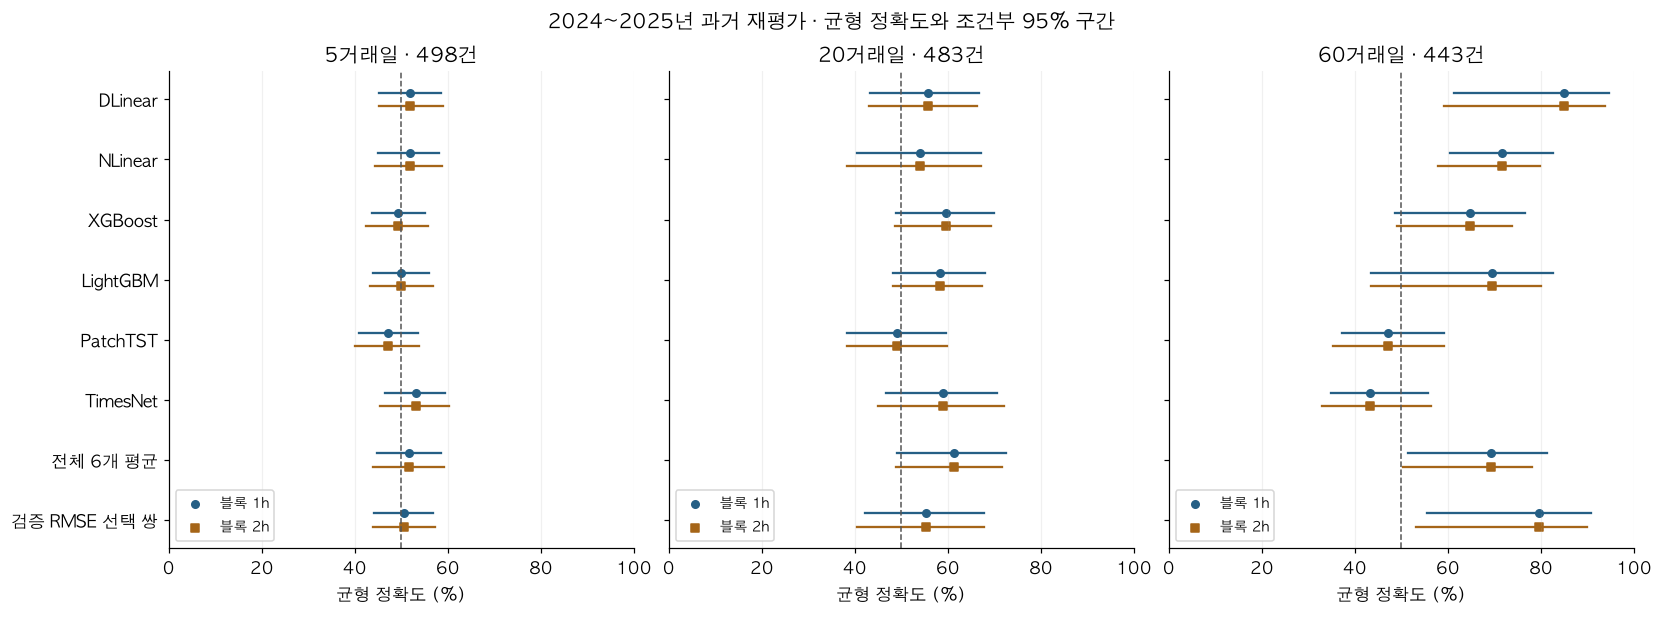

In [8]:
# 점과 구간: 같은 축으로 모델별 균형 정확도와 블록 길이 민감도를 비교한다.
plot_names = [*MODELS, "전체 6개 평균", "검증 RMSE 선택 쌍"]
fig, axes = plt.subplots(1, 3, figsize=(15, 5.5), sharey=True, constrained_layout=True)
for ax, h in zip(axes, HORIZONS):
    point = direction_scores.loc[direction_scores["지평"].eq(h)].set_index("모델")
    for j, (multiplier, color, marker) in enumerate(((1, "#255F85", "o"), (2, "#A56518", "s"))):
        ci = direction_intervals.loc[(direction_intervals["지평"] == h) &
                                     (direction_intervals["블록"] == multiplier*h)].set_index("모델")
        for pos, name in enumerate(plot_names):
            row, y_pos = ci.loc[name], pos+(j-.5)*.22
            ax.plot([row["균형 95% 하한"], row["균형 95% 상한"]], [y_pos, y_pos], color=color)
            ax.scatter(point.loc[name, "균형 정확도 (%)"], y_pos, color=color, marker=marker,
                       s=24, label=f"블록 {multiplier}h" if pos == 0 else None)
    ax.axvline(50, color="#555555", linestyle="--", linewidth=1)
    ax.set(xlim=(0, 100), title=f"{h}거래일 · {int(point.iloc[0]['표본'])}건",
           xlabel="균형 정확도 (%)", yticks=range(len(plot_names)), yticklabels=plot_names)
    ax.grid(axis="x", alpha=.18)
    ax.legend(loc="lower left", fontsize=9)
axes[0].invert_yaxis()
fig.suptitle("2024~2025년 과거 재평가 · 균형 정확도와 조건부 95% 구간")
plt.show()

## 14. 방향 적중을 구매 비용으로 연결하는 최소 시나리오

같은 수량을 h일 뒤에 반드시 사용한다고 가정하고, **지금 선매수** 또는 **h일 뒤 매수**만 비교한다. 이미 보유한 안전재고로 h일까지의 수요를 충족할 수 있다는 가정이다. 기준일 가격을 1로 두면 지금 사는 비용은 `1+c`, 나중에 사는 비용은 `exp(actual_return)`이다. c는 지평 전체의 보관·자금·품질 손실 비용 비율이며 **0%, 1%, 2%는 실측이 아닌 민감도 시나리오**다. 예측 상승폭이 c를 넘을 때만 선매수한다.

`항상 지금 대비 절감(pp) = 100 × 평균[(1+c) − 정책 비용]`이다. 각 날짜의 기준일 가격으로 정규화한 비용 차이이며, 전체 구매 예산의 절감률이나 실현 손익은 아니다. 항상 나중 매수와도 비교하고, 실제 두 가격을 미리 아는 최저비용 선택과의 격차를 기회손실로 표시한다. 날짜별 가상 의사결정은 서로 중첩되므로 누적 손익으로 합산하지 않는다.

**한계:** KC 선물가격을 원두 실물 매입가격의 대리값으로 쓴다. 환율·원산지/등급 프리미엄·운송·납기·계약·수요·현재 재고·최소 주문량이 없으므로 실제 주문량, 품절률, 원화 비용을 검증한 결과가 아니다. 동일 시점 종가에 즉시 체결할 수 있다는 가정도 실매수 검증에서 바꿔야 한다. 예측 로그수익률을 가격으로 변환한 값은 조건부 기대가격과 같다고 보장되지 않는다.

In [9]:
def purchase_cost(actual, predicted, carrying):
    direction_metrics(actual, predicted)
    if not np.isfinite(carrying) or carrying < 0:
        raise ValueError("추가 비용은 유한한 비음수여야 합니다.")
    actual, predicted = np.asarray(actual, dtype=float), np.asarray(predicted, dtype=float)
    later = np.exp(actual)
    if not np.isfinite(later).all():
        raise ValueError("복원한 실제 가격이 유한하지 않습니다.")
    buy = predicted > np.log1p(carrying)
    cost = np.where(buy, 1+carrying, later)
    return buy, cost, later

purchase_rows = []
for h, (reference, predictions) in direction_panels.items():
    for carrying in (0., .01, .02):
        for name in (*DIRECTION_MODELS, "항상 지금 매수", "항상 나중 매수"):
            if name in predictions:
                buy, cost, later = purchase_cost(reference.actual_return, predictions[name], carrying)
            else:
                later = np.exp(reference.actual_return.to_numpy())
                buy = np.full(len(later), name == "항상 지금 매수")
                cost = np.where(buy, 1+carrying, later)
            purchase_rows.append({"지평": h, "추가 비용 (%)": 100*carrying, "모델": name,
                "선매수 비중 (%)": 100*buy.mean(),
                "항상 지금 대비 절감 (pp)": 100*np.mean(1+carrying-cost),
                "항상 나중 대비 절감 (pp)": 100*np.mean(later-cost),
                "사후 최저비용 대비 기회손실 (pp)": 100*np.mean(cost-np.minimum(1+carrying, later))})
purchase_scores = pd.DataFrame(purchase_rows)
show_table(purchase_scores.loc[purchase_scores["추가 비용 (%)"].eq(1)], digits=2)
print("0%·1%·2% 전체 시나리오는 저장 metrics.csv의 구매 시나리오 표에 포함한다.")

# 보합·무신호·한쪽 클래스·매수 비용의 의미를 손으로 검산할 수 있는 작은 검사
probe = direction_metrics([.1, -.1, 0, .2], [.1, .1, 0, 0])
assert probe["방향 적중률 (%)"] == 50 and probe["균형 정확도 (%)"] == 25
assert probe["상승 정밀도 (%)"] == 50 and probe["상승 누락률 (%)"] == 50
assert np.isnan(direction_metrics([1., 2.], [0., 0.])["균형 정확도 (%)"])
assert np.isnan(direction_metrics([1., -1.], [0., 0.])["상승 정밀도 (%)"])
ci = direction_block_interval([1., -1., 1., -1.], [1., -1., 1., -1.], 2)
assert ci["균형 95% 하한"] == ci["균형 95% 상한"] == 100
assert ci["차이 95% 하한"] == ci["차이 95% 상한"] == 50
buy, cost, _ = purchase_cost(np.log([1.2, .8]), np.log([1.2, .8]), .01)
np.testing.assert_array_equal(buy, [True, False])
np.testing.assert_allclose(cost, [1.01, .8])
for actual, predicted in (([], []), ([1], [1, 2]), ([np.nan], [1])):
    try:
        direction_metrics(actual, predicted)
    except ValueError:
        pass
    else:
        raise AssertionError("잘못된 지표 입력이 허용됐습니다.")
assert not direction_predictions.duplicated(["horizon", "candidate", "origin_date"]).any()
assert (purchase_scores["사후 최저비용 대비 기회손실 (pp)"] >= -1e-10).all()
for h in HORIZONS:
    row = direction_scores.loc[(direction_scores["지평"] == h) & direction_scores["모델"].eq("항상 상승")].iloc[0]
    assert row["방향 적중률 (%)"] == row["실제 상승 (%)"]
    assert row["균형 정확도 (%)"] == 50
DIRECTION_OUTPUT = ENSEMBLE_SOURCE / "direction_purchase_v1"
direction_tables = pd.concat([direction_scores.assign(표="방향 전체"),
    direction_intervals.assign(표="방향 블록 구간"), purchase_scores.assign(표="구매 시나리오")], ignore_index=True)
save_results(DIRECTION_OUTPUT, direction_predictions, direction_tables, direction_yearly, direction_offsets)
print("검사 통과: 기존 방향 지표 대조·보합/무신호·클래스 결측·블록 구간·구매 비용·중복")
print("저장:", DIRECTION_OUTPUT.relative_to(ROOT))

|   지평 |   추가 비용 (%) | 모델              |   선매수 비중 (%) |   항상 지금 대비 절감 (pp) |   항상 나중 대비 절감 (pp) |   사후 최저비용 대비 기회손실 (pp) |
|-------:|----------------:|:------------------|------------------:|---------------------------:|---------------------------:|-----------------------------------:|
|      5 |            1.00 | DLinear           |             24.90 |                       0.14 |                      -0.07 |                               2.12 |
|      5 |            1.00 | NLinear           |             16.67 |                       0.14 |                      -0.08 |                               2.13 |
|      5 |            1.00 | XGBoost           |             45.18 |                      -0.05 |                      -0.26 |                               2.31 |
|      5 |            1.00 | LightGBM          |             40.76 |                      -0.08 |                      -0.30 |                               2.35 |
|      5 |            1.00 | PatchTST          |             38.96 |                       0.26 |                       0.05 |                               2.00 |
|      5 |            1.00 | TimesNet          |             34.54 |                       0.27 |                       0.06 |                               1.99 |
|      5 |            1.00 | 전체 6개 평균     |             31.73 |                       0.20 |                      -0.02 |                               2.07 |
|      5 |            1.00 | 검증 RMSE 선택 쌍 |             25.30 |                       0.28 |                       0.07 |                               1.98 |
|      5 |            1.00 | Persistence       |              0.00 |                       0.21 |                       0.00 |                               2.05 |
|      5 |            1.00 | 항상 지금 매수    |            100.00 |                       0.00 |                      -0.21 |                               2.26 |
|      5 |            1.00 | 항상 나중 매수    |              0.00 |                       0.21 |                       0.00 |                               2.05 |
|     20 |            1.00 | DLinear           |             35.61 |                      -0.07 |                       2.47 |                               3.18 |
|     20 |            1.00 | NLinear           |             48.24 |                      -0.73 |                       1.80 |                               3.85 |
|     20 |            1.00 | XGBoost           |             38.10 |                      -0.78 |                       1.75 |                               3.89 |
|     20 |            1.00 | LightGBM          |             37.06 |                      -0.64 |                       1.90 |                               3.75 |
|     20 |            1.00 | PatchTST          |             48.65 |                      -1.18 |                       1.36 |                               4.29 |
|     20 |            1.00 | TimesNet          |             51.35 |                      -0.31 |                       2.22 |                               3.43 |
|     20 |            1.00 | 전체 6개 평균     |             42.24 |                      -0.33 |                       2.20 |                               3.45 |
|     20 |            1.00 | 검증 RMSE 선택 쌍 |             46.79 |                      -0.46 |                       2.07 |                               3.57 |
|     20 |            1.00 | Persistence       |              0.00 |                      -2.54 |                       0.00 |                               5.65 |
|     20 |            1.00 | 항상 지금 매수    |            100.00 |                       0.00 |                       2.54 |                               3.11 |
|     20 |            1.00 | 항상 나중 매수    |              0.00 |                      -2.54 |                       0.00 |                               5.65 |
|     60 |            1.00 | DLinear           |             62.75 |                      -0.28 |                      10.39 |                               3.21 |
|     60 |            1.00 | NLinear           |             54.18 |                      -1.87 |                       8.80 |                               4.80 |
|     60 |            1.00 | XGBoost           |             40.18 |                      -4.58 |                       6.08 |                               7.51 |
|     60 |            1.00 | LightGBM          |             41.08 |                      -3.83 |                       6.84 |                               6.76 |
|     60 |            1.00 | PatchTST          |             71.78 |                      -2.80 |                       7.87 |                               5.73 |
|     60 |            1.00 | TimesNet          |             77.43 |                      -3.31 |                       7.35 |                               6.24 |
|     60 |            1.00 | 전체 6개 평균     |             64.11 |                      -1.22 |                       9.45 |                               4.15 |
|     60 |            1.00 | 검증 RMSE 선택 쌍 |             54.18 |                      -1.48 |                       9.18 |                               4.41 |
|     60 |            1.00 | Persistence       |              0.00 |                     -10.66 |                       0.00 |                              13.60 |
|     60 |            1.00 | 항상 지금 매수    |            100.00 |                       0.00 |                      10.66 |                               2.93 |
|     60 |            1.00 | 항상 나중 매수    |              0.00 |                     -10.66 |                       0.00 |                              13.60 |

0%·1%·2% 전체 시나리오는 저장 metrics.csv의 구매 시나리오 표에 포함한다.
검사 통과: 기존 방향 지표 대조·보합/무신호·클래스 결측·블록 구간·구매 비용·중복
저장: data/processed/single_model_comparison/20260926T115735770501Z/direction_purchase_v1


## 15. 외부 예측 사례와 다음 실험

조사일: **2026-09-28**. 논문의 보고 결과와 이 프로젝트에 대한 제안을 구분한다. 월평균 가격의 한 달 앞 예측은 일별 종가의 20거래일 후 예측과 목표가 다르다. 아래 모델의 커피 5/20일 우월성을 입증한 것은 아니다.

| 적용 지평 | 원문에서 확인한 사례 | 이 프로젝트에 참고할 점과 한계 |
|---|---|---|
| 5·20거래일 방향 | [Wang, Stanford CS229 (2016)](https://cs229.stanford.edu/proj2016/poster/Wang-Forecasting%20Agricultural%20Commodity%20Prices%20through%20Supervised%20Learning-Poster.pdf): 옥수수 선물의 5/10/15/20일 상승·하락을 Logistic Regression과 SVM으로 분류. 이동평균 괴리·만기 스프레드·대두/원유 정보를 사용하며 저자는 SVM 우세를 보고. | 회귀 출력의 부호 외에 방향을 직접 학습하는 비교가 필요하다. 학생 프로젝트이며 랜덤/순차 분할을 함께 다뤘다. 그래프에서 정확한 수치를 추측하지 않았고 강한 재현 근거로 취급하지 않는다. |
| 약 1개월 가격 | [Kadir 등, Forecasting (2026)](https://www.mdpi.com/2571-9394/8/4/73): 월별 Robusta의 한 시점 앞 walk-forward 비교에서 XGBoost RMSE 0.264, Naïve 0.271, ARIMA 0.270. XGBoost의 수치상 개선은 약 2.6%이나 DM 검정의 유의한 우월성은 없다고 보고. | XGBoost와 ARIMA/ARIMAX를 작은 비교군으로 유지할 근거다. 월평균 Robusta 결과를 Arabica 일별 KC의 20일 방향 정확도로 전용하지 않는다. |
| 1·3·6·12개월 가격 | [A methodology for coffee price forecasting based on extreme learning machines (2022)](https://www.sciencedirect.com/science/article/pii/S2214317321000597): 브라질 월평균 현물가격을 차분·PACF 시차 선택 후 직접 다중 지평 예측. Arabica에서 ELM이 ES/AR/ARIMA/MLP보다 오차 지표상 우수한 결과를 보고. | 모델 크기보다 정상성 처리와 시차 선택도 실험할 가치가 있다. Persistence와 방향 정확도 비교가 제시된 이 프로젝트와 동등한 검증은 아니며, 전처리·시차 선택은 각 학습 구간 안에서만 수행해야 한다. |
| 1주·약 1개월 변동성 | [Alfeus·Nikitopoulos, Journal of Commodity Markets (2022), 저자 원고](https://opus.lib.uts.edu.au/bitstream/10453/164057/3/Forecasting%20volatility%20in%20commodity%20markets.pdf): 22개 상품의 고빈도 자료로 HAR/FIGARCH/FSV를 비교. HAR가 대체로 우수하며 일부 상품의 5/22일에는 fractional 모형이 개선. | 가격의 상승·하락과 변동성 크기는 별도 목표다. 위험 한도에 변동성 예측을 보조적으로 붙일 수 있지만 수요 불확실성 기반 안전재고를 대체하지 않는다. 원문은 고빈도 realized volatility를 사용하므로 일별 가격만으로 같은 실험을 재현했다고 할 수 없다. |

| 다음 날 뉴스 결합(5/20일 직접 근거는 아님) | [AI-Driven News-Enhanced Machine Learning for Short-Term Corn Futures Price Forecasting (2026)](https://www.mdpi.com/2076-3417/16/3/1337): LSTM 잔차를 뉴스 보도량·지속성 기반 Ridge로 보정해 방향 적중률 49.2%→51.6%를 보고. 감성 tone 계수는 0. | 뉴스 감성뿐 아니라 보도 강도·지속성을 분리 실험할 근거다. 논문의 무변화 Naive에도 49.2% 방향 점수가 있어, 부호 기준을 그대로 적용하면 무신호인 이 노트북과 정의가 일치하는지 추가 확인이 필요하다. 보고치를 그대로 재현·전용하지 않는다. |

### 제안: 지평별 방향 분류와 비용 평가를 먼저 비교

- **5일:** 정규화 Logistic Regression → LightGBM/XGBoost classifier 순으로 작은 비교. `P(5일 수익률 > 비용 임계값)`을 직접 예측하고 1/5/20일 수익률·거래량 변화·변동성·최신 뉴스의 감성·보도량·지속성 및 기상 예보의 추가 효과를 따로 검사한다. 관측 기후와 그때 발표된 기상 예보는 다르며 미래 관측치를 입력하지 않는다. 이는 후속 제안이고 이번에 학습한 결과가 아니다.
- **20일:** XGBoost/LightGBM의 방향 분류와 수익률/분위수 회귀를 비교하고 ARIMAX를 작은 기준으로 둔다. 현재 6개 평균도 고정 후보로 유지한다. 누적 기후 이상·재고·수출·환율·발표 시점별 수급 정보를 단계적으로 추가하되, 새 자료의 획득·이용 가능성을 먼저 확인한다.
- **60일:** 이번 DLinear의 방향 성능과 전체 평균의 가격 오차 성능은 따로 평가한다. 장기 계약·재고 예산 후보로 새 기간에서 관찰하며 5일 매수 타이밍 성능으로 해석하지 않는다.
- 지평별 direct 모델, rolling/expanding 학습 창, 재학습 주기를 검증 구간에서 결정한다. 학습 시 정답이 성숙한 행만 포함하고 클래스 기준·확률 보정·앙상블 구성·구매 임계값도 시간순 검증에서 고정한다. 확률을 앙상블한다면 같은 사건을 예측하는 보정된 확률의 **단순평균**부터 비교한다.
- 방향은 균형 정확도·상승 정밀도/누락률, 확률은 Brier/log loss·calibration, 크기는 RMSE/MAE·분위수 pinball loss, 최종 의사결정은 총 매입+보유+품절 비용과 서비스 수준으로 평가한다. 항상 상승/하락과 과거 모멘텀을 방향 기준, 정기 분할매수를 구매 기준으로 둔다. 이 기준들과 임계값은 새 평가 기간을 보기 전에 고정한다.
- 실제 주문량 최적화에는 수요·현재 재고·입고 예정량·리드타임·품질/보관 제약이 필요하다. 가격 방향만으로 필수 물량 구매를 중단하는 정책은 이 실험으로 도출할 수 없다.

**뉴스 상태 구분:** 앞 절의 저장 출력은 2026-09-26 당시 제목 규칙/88건 Jev 점검이다. 이후 프로젝트의 Jev 자료가 통합·확장됐더라도 그 출력이 새 뉴스 데이터의 성능 검증으로 바뀌지는 않는다. 이번 방향 평가는 기존 가격 모델과 평균의 예측만 사용하고 뉴스 재학습/서비스 변경은 하지 않았다.

### 실행 결과의 해석

아래 요약은 위 계산값에서 생성한다. 높은 적중률이 비용 절감을 보장하는지, 연도별로 같은 성능인지 함께 읽는다. 사후 순위로 모델을 교체하지 않는다.

In [10]:
for h in HORIZONS:
    eligible = direction_scores.loc[direction_scores["지평"].eq(h) &
        direction_scores["모델"].isin((*MODELS, "전체 6개 평균"))]
    best = eligible.sort_values(["균형 정확도 (%)", "모델"], ascending=[False, True]).iloc[0]
    name = best["모델"]
    ci = direction_intervals.loc[(direction_intervals["지평"] == h) &
        direction_intervals["모델"].eq(name) & (direction_intervals["블록"] == 2*h)].iloc[0]
    cost = purchase_scores.loc[(purchase_scores["지평"] == h) & purchase_scores["모델"].eq(name) &
                              purchase_scores["추가 비용 (%)"].eq(1)].iloc[0]
    display(Markdown(f"- **{h}일 사후 균형 정확도 최고: {name}**. 적중률 {best['방향 적중률 (%)']:.2f}%, "
        f"균형 정확도 {best['균형 정확도 (%)']:.2f}% "
        f"(블록 2h 조건부 95% 구간 {ci['균형 95% 하한']:.2f}~{ci['균형 95% 상한']:.2f}%). "
        f"항상 상승 적중률은 {best['실제 상승 (%)']:.2f}%. 상승 정밀도 {best['상승 정밀도 (%)']:.2f}%, "
        f"상승 누락률 {best['상승 누락률 (%)']:.2f}%. "
        f"추가 비용 1% 가정의 항상 지금 대비 비용 절감은 {cost['항상 지금 대비 절감 (pp)']:+.2f}pp, "
        f"항상 나중 대비 {cost['항상 나중 대비 절감 (pp)']:+.2f}pp다."))
    sub = direction_yearly.loc[(direction_yearly['지평'] == h) & direction_yearly['모델'].eq(name)]
    show_table(sub[["연도", "표본", "실제 상승 수", "실제 하락 수", "균형 정확도 (%)"]], digits=2)
display(Markdown("**구매 해석:** 위 비용은 정규화한 날짜별 가상 비용 차이다. 음수는 비교 정책보다 비용이 더 들었다는 뜻이다. "
    "상승 누락 횟수뿐 아니라 놓친 상승폭과 보유 비용이 중요하다. 특히 60일은 연도별 실제 하락 표본 수가 크게 달라 "
    "전체 균형 정확도만으로 국면 전반의 안정성을 주장하지 않는다. 방향 비교 결과를 실제 원두 매입비 절감으로 확정할 수 없다."))

- **5일 사후 균형 정확도 최고: TimesNet**. 적중률 52.61%, 균형 정확도 53.12% (블록 2h 조건부 95% 구간 45.48~60.31%). 항상 상승 적중률은 54.82%. 상승 정밀도 58.30%, 상승 누락률 49.82%. 추가 비용 1% 가정의 항상 지금 대비 비용 절감은 +0.27pp, 항상 나중 대비 +0.06pp다.

|    연도 |   표본 |   실제 상승 수 |   실제 하락 수 |   균형 정확도 (%) |
|--------:|-------:|---------------:|---------------:|------------------:|
| 2024.00 | 252.00 |         146.00 |         106.00 |             52.82 |
| 2025.00 | 246.00 |         127.00 |         117.00 |             52.49 |

- **20일 사후 균형 정확도 최고: 전체 6개 평균**. 적중률 60.87%, 균형 정확도 61.37% (블록 2h 조건부 95% 구간 48.84~71.73%). 항상 상승 적중률은 59.83%. 상승 정밀도 70.83%, 상승 누락률 41.18%. 추가 비용 1% 가정의 항상 지금 대비 비용 절감은 -0.33pp, 항상 나중 대비 +2.20pp다.

|    연도 |   표본 |   실제 상승 수 |   실제 하락 수 |   균형 정확도 (%) |
|--------:|-------:|---------------:|---------------:|------------------:|
| 2024.00 | 252.00 |         179.00 |          73.00 |             48.77 |
| 2025.00 | 231.00 |         110.00 |         121.00 |             62.48 |

- **60일 사후 균형 정확도 최고: DLinear**. 적중률 81.94%, 균형 정확도 85.02% (블록 2h 조건부 95% 구간 59.23~93.86%). 항상 상승 적중률은 79.01%. 상승 정밀도 96.88%, 상승 누락률 20.29%. 추가 비용 1% 가정의 항상 지금 대비 비용 절감은 -0.28pp, 항상 나중 대비 +10.39pp다.

|    연도 |   표본 |   실제 상승 수 |   실제 하락 수 |   균형 정확도 (%) |
|--------:|-------:|---------------:|---------------:|------------------:|
| 2024.00 | 252.00 |         247.00 |           5.00 |             51.50 |
| 2025.00 | 191.00 |         103.00 |          88.00 |             83.08 |

**구매 해석:** 위 비용은 정규화한 날짜별 가상 비용 차이다. 음수는 비교 정책보다 비용이 더 들었다는 뜻이다. 상승 누락 횟수뿐 아니라 놓친 상승폭과 보유 비용이 중요하다. 특히 60일은 연도별 실제 하락 표본 수가 크게 달라 전체 균형 정확도만으로 국면 전반의 안정성을 주장하지 않는다. 방향 비교 결과를 실제 원두 매입비 절감으로 확정할 수 없다.